In [ ]:
# Libraries to install
!pip install medmnist
!pip install torch torchvision
!pip install dill

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fire: filename=fire-0.7.0-py3-none-any.whl size=114249 sha256=ac539e934957bbd3541f1fa0398c4cece69ce36e0cd3021dcc14c6c92cf1df1a
  Stored in directory: /root/.cache/pip/wheels/19/39/2f/2d3cadc408a8804103f1c34ddd4b9f6a93497b11fa96fe738e
Successfully built fire
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 2.9 MB/s eta 0:00:00


In [ ]:
# Packages
from medmnist import OrganAMNIST
from torchvision import transforms
from torch.utils.data import DataLoader
import torch
import matplotlib.pyplot as plt
import numpy as np
import time

In [ ]:
# To save and load models
# Make sure to have a top level folder called COMP551_A3 in Google Drive
import dill as pickle
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## Data Preprocessing


In [ ]:
# Function to calculate mean and standard deviation
def mean_var_calc(dataset_name='OrganAMNIST', size=28):
    if dataset_name == 'OrganAMNIST':
        # Use ToTensor() for initial transformation
        transform = transforms.Compose([transforms.ToTensor()])
        train_data = OrganAMNIST(split="train", transform=transform, download=True, size=size)
    else:
        raise ValueError(f"Dataset {dataset_name} not supported")

    # Create a DataLoader with a batch size of 1000 for efficient calculation
    train_loader = DataLoader(train_data, batch_size=1000, shuffle=False)

    # Initialize accumulators for mean and standard deviation calculation
    sum, squared_sum, N = 0.0, 0.0, 0

    # Accumulate sums to calculate mean and std
    for data, _ in train_loader:
        sum += data.sum(dim=[0, 2, 3])
        squared_sum += (data ** 2).sum(dim=[0, 2, 3])
        N += data.numel()

    # Calculate mean and standard deviation
    mean = sum / N
    std = torch.sqrt((squared_sum / N) - (mean ** 2))
    return mean.item(), std.item()

In [ ]:
# Function to set random seed for reproducibility across Pytorch operations
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [ ]:
# Function to convert DataLoader to NumPy arrays
def data_loader_to_numpy(data_loader):
    X_list = []
    y_list = []
    for data, labels in data_loader:
        X_list.append(data.numpy())
        y_list.append(labels.numpy())
    X = np.vstack(X_list)
    y = np.concatenate(y_list).astype(int).flatten()
    return X, y

### Loading dataset

In [ ]:
# Set a seed for reproducibility
set_seed(42)

# Calculate the mean and standard deviation for OrganAMNIST, size=28
mean, std = mean_var_calc('OrganAMNIST', size=28)
print("Calculated Mean:", mean)
print("Calculated Standard Deviation:", std)

Using downloaded and verified file: /root/.medmnist/organamnist.npz
Calculated Mean: 0.4680282771587372
Calculated Standard Deviation: 0.2974208891391754


In [ ]:
# Define data transformations with calculated mean and std
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[mean], std=[std]),  # Normalize using calculated mean and std
    transforms.Lambda(lambda x: x.view(-1))        # Flatten the images to 28×28-dimensional vectors
])

# Load OrganAMNIST dataset (train, validation, and test datasets without normalization)
train_data = OrganAMNIST(split="train", transform=transform, download=True)
val_data = OrganAMNIST(split="val", transform=transform, download=True)
test_data = OrganAMNIST(split="test", transform=transform, download=True)

# Create DataLoaders for each split
batch_size = 64
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

# Convert data from PyTorch tensors to NumPy arrays
X_train, y_train = data_loader_to_numpy(train_loader)
X_val, y_val = data_loader_to_numpy(val_loader)
X_test, y_test = data_loader_to_numpy(test_loader)

# Check the shapes of the datasets
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

Using downloaded and verified file: /root/.medmnist/organamnist.npz
Using downloaded and verified file: /root/.medmnist/organamnist.npz
Using downloaded and verified file: /root/.medmnist/organamnist.npz
X_train shape: (34561, 784)
y_train shape: (34561,)
X_val shape: (6491, 784)
y_val shape: (6491,)
X_test shape: (17778, 784)
y_test shape: (17778,)


### Test for normalization and vectorization

In [ ]:
# Get a batch from the train loader to test
data_iter = iter(train_loader)
images, labels = next(data_iter)

# 1. Check if the images are flattened correctly (from [64, 1, 28, 28] to [64, 784])
print(f"Original batch shape: {images.shape}")  # Should print [64, 784]

# 2. Verify the min and max values after normalization (values should be ~[-1, 1] range)
print(f"Min value after normalization: {images.min().item()}")
print(f"Max value after normalization: {images.max().item()}")

# 3. Compute the mean and standard deviation of the batch to ensure it's ~0 mean and ~1 std
batch_mean = images.mean().item()
batch_std = images.std().item()
print(f"Batch mean: {batch_mean:.4f}")  # Should be close to 0
print(f"Batch std: {batch_std:.4f}")    # Should be close to 1

Original batch shape: torch.Size([64, 784])
Min value after normalization: -1.573622703552246
Max value after normalization: 1.7886158227920532
Batch mean: 0.0071
Batch std: 1.0439


* Flattening check confirms that the images are properly flattened from their original shape [64, 1, 28, 28] to [64, 784].
* The normalization values are within a reasonable range around [-1, 1]. The slight deviation could be because not every batch will contain the full range of pixel intensities
* The value for batch mean is close to 0
* The value for batch standard deviation is close to 1


### Exploring the dataset

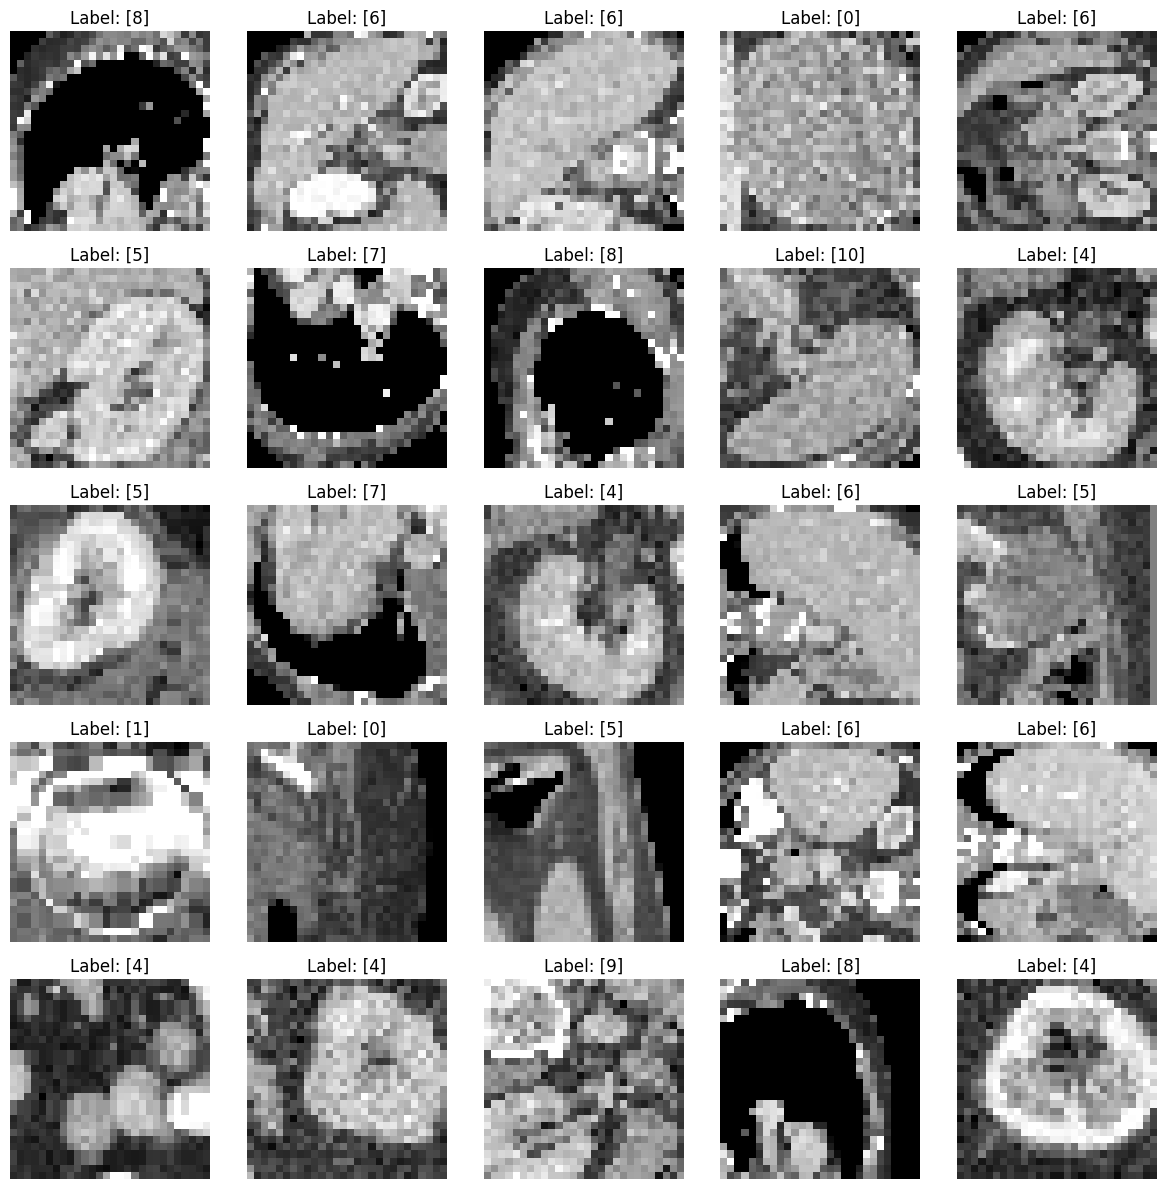

In [ ]:
# Visualizing the OrganAMNIST images
sample_img_idx = np.random.randint(0, len(train_data), 25)  # Randomly sample 25 images
plt.figure(figsize=(12, 12))

for i, j in enumerate(sample_img_idx):
    image, label = train_data[j]

    # Reshape the image if it is flattened
    if image.ndim == 1:
        side_length = int(np.sqrt(image.shape[0]))            # Assuming the image is square
        image = image.reshape(side_length, side_length)
    elif image.ndim == 3 and image.shape[0] == 1:             # For channels-first grayscale format
        image = image.squeeze(axis=0)                         # Remove the channel dimension

    ax = plt.subplot(5, 5, i + 1)
    plt.imshow(image, cmap='gray')
    plt.title(f"Label: {label}")
    plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
train_data.info

{'python_class': 'OrganAMNIST',
 'description': 'The OrganAMNIST is based on 3D computed tomography (CT) images from Liver Tumor Segmentation Benchmark (LiTS). It is renamed from OrganMNIST_Axial (in MedMNIST v1) for simplicity. We use bounding-box annotations of 11 body organs from another study to obtain the organ labels. Hounsfield-Unit (HU) of the 3D images are transformed into gray-scale with an abdominal window. We crop 2D images from the center slices of the 3D bounding boxes in axial views (planes). The images are resized into 1×28×28 to perform multi-class classification of 11 body organs. 115 and 16 CT scans from the source training set are used as training and validation set, respectively. The 70 CT scans from the source test set are treated as the test set.',
 'url': 'https://zenodo.org/records/10519652/files/organamnist.npz?download=1',
 'MD5': '68e3f8846a6bd62f0c9bf841c0d9eacc',
 'url_64': 'https://zenodo.org/records/10519652/files/organamnist_64.npz?download=1',
 'MD5_64

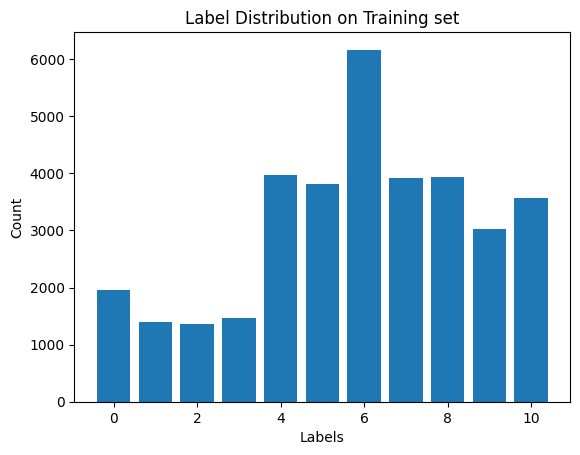

In [ ]:
# Observing dataset label distribution

labels, counts = np.unique(train_data.labels, return_counts=True)

# Plot histogram
plt.bar(labels, counts)
plt.xlabel('Labels')
plt.ylabel('Count')
plt.title('Label Distribution on Training set')
plt.show()

## MLP Implementation

### Defining the MLP class

In [ ]:
# Define the MLP class

class MLP:
    def __init__(self, activation_function='relu', num_hidden_layers=2, hidden_units=[64, 64],
                 input_dim=None, output_dim=None, learning_rate=0.01, reg_type=None, reg_strength=None, leaky_alpha=0.01):
        np.random.seed(42)

        def leaky_relu(Z, alpha=leaky_alpha):
            return np.where(Z > 0, Z, alpha * Z)

        def leaky_relu_derivative(Z, alpha=leaky_alpha):
            return np.where(Z > 0, 1, alpha)

        # Set activation function and derivative
        if activation_function == 'relu':
            self.activation = self.relu
            self.activation_derivative = self.relu_derivative
        elif activation_function == 'tanh':
            self.activation = self.tanh
            self.activation_derivative = self.tanh_derivative
        elif activation_function == 'leaky_relu':
            self.activation = leaky_relu
            self.activation_derivative = leaky_relu_derivative
        else:
            raise ValueError("Unsupported activation function")

        self.num_hidden_layers = num_hidden_layers
        self.hidden_units = hidden_units
        self.learning_rate = learning_rate
        self.train_acc_history = []
        self.val_acc_history = []
        self.train_loss_history = []
        self.val_loss_history = []

        if reg_type not in ['L1', 'L2', None]:
            raise ValueError("Unsupported regularization type: please input either 'L1', 'L2', or None.")

        self.reg_type = reg_type              # Regularization type: 'L1' or 'L2'
        self.reg_strength = reg_strength      # Regularization strength

        # Initialize weights and biases
        self.weights = []
        self.biases = []
        layer_dims = [input_dim] + hidden_units + [output_dim]
        for i in range(len(layer_dims) - 1):
            # He initialization for ReLU activation
            W = np.random.randn(layer_dims[i], layer_dims[i + 1]) * np.sqrt(2 / layer_dims[i])
            b = np.zeros((1, layer_dims[i + 1]))
            self.weights.append(W)
            self.biases.append(b)

    # Activation functions and derivatives
    def relu(self, Z):
        return np.maximum(0, Z)

    def relu_derivative(self, Z):
        return (Z > 0).astype(float)

    def softmax(self, Z):
        expZ = np.exp(Z - np.max(Z, axis=1, keepdims=True))  # Numerical stability
        return expZ / np.sum(expZ, axis=1, keepdims=True)

    def softmax_derivative(Z):
        # Placeholder, not explicitly used since softmax is coupled with cross-entropy loss
        return Z

    def tanh(self, Z):
        return np.tanh(Z)

    def tanh_derivative(self, Z):
        return 1 - np.tanh(Z) ** 2


    # Loss function
    def cross_entropy_loss(self, y_true, y_pred):
        m = y_true.shape[0]
        # Add epsilon to prevent log(0)
        epsilon = 1e-12
        y_pred = np.clip(y_pred, epsilon, 1. - epsilon)
        log_probs = -np.log(y_pred[range(m), y_true])
        loss = np.sum(log_probs) / m
        return loss

    # Forward propagation
    def forward_propagation(self, X):
        activations = [X]
        Zs = []
        for idx in range(len(self.weights) - 1):
            Z = np.dot(activations[-1], self.weights[idx]) + self.biases[idx]
            Zs.append(Z)
            A = self.activation(Z)
            activations.append(A)
        # Output layer with softmax activation
        Z = np.dot(activations[-1], self.weights[-1]) + self.biases[-1]
        Zs.append(Z)
        A = self.softmax(Z)
        activations.append(A)
        return activations, Zs

    # Backward propagation
    def backward_propagation(self, activations, Zs, y_true):
        grads_W = []
        grads_b = []

        m = y_true.shape[0]
        y_one_hot = np.zeros_like(activations[-1])
        y_one_hot[np.arange(m), y_true] = 1

        # Gradient at the output layer
        dZ = activations[-1] - y_one_hot  # (m, output_dim)
        dW = np.dot(activations[-2].T, dZ) / m
        db = np.sum(dZ, axis=0, keepdims=True) / m
        grads_W.append(dW)
        grads_b.append(db)

        # Apply L1 or L2 regularization to output layer
        if self.reg_type == 'L2':
             dW += (self.reg_strength * self.weights[-1]) / m
        elif self.reg_type == 'L1':
             dW += (self.reg_strength * np.sign(self.weights[-1])) / m

        # Backpropagate through hidden layers
        for idx in reversed(range(len(self.weights) - 1)):
            dA = np.dot(dZ, self.weights[idx + 1].T)
            dZ = dA * self.activation_derivative(Zs[idx])
            dW = np.dot(activations[idx].T, dZ) / m
            db = np.sum(dZ, axis=0, keepdims=True) / m

            # Apply L1 or L2 regularization to hidden layers
            if self.reg_type == 'L2':
                dW += (self.reg_strength * self.weights[idx]) / m
            elif self.reg_type == 'L1':
                dW += (self.reg_strength * np.sign(self.weights[idx])) / m
            grads_W.append(dW)
            grads_b.append(db)

        # Reverse the gradients to match the order of weights
        grads_W = grads_W[::-1]
        grads_b = grads_b[::-1]

        return grads_W, grads_b

    # Update parameters
    def update_parameters(self, grads_W, grads_b):
        for idx in range(len(self.weights)):
            self.weights[idx] -= self.learning_rate * grads_W[idx]
            self.biases[idx] -= self.learning_rate * grads_b[idx]

    # Fit function
    def fit(self, X, y, X_val, y_val, num_iterations=50, batch_size=64):
        m = X.shape[0]
        num_batches = int(np.ceil(m / batch_size))
        for epoch in range(num_iterations):
            permutation = np.random.permutation(m)
            X_shuffled = X[permutation]
            y_shuffled = y[permutation]

            for i in range(num_batches):
                start_idx = i * batch_size
                end_idx = min(start_idx + batch_size, m)
                X_batch = X_shuffled[start_idx:end_idx]
                y_batch = y_shuffled[start_idx:end_idx]

                # Forward propagation
                activations, Zs = self.forward_propagation(X_batch)

                # Backward propagation
                grads_W, grads_b = self.backward_propagation(activations, Zs, y_batch)

                # Update parameters
                self.update_parameters(grads_W, grads_b)

            y_pred_train = self.predict(X)
            accuracy_train = self.evaluate_acc(y, y_pred_train)
            loss_train = self.cross_entropy_loss(y, self.forward_propagation(X)[0][-1])

            y_pred_val = self.predict(X_val)
            accuracy_val = self.evaluate_acc(y_val, y_pred_val)
            loss_val = self.cross_entropy_loss(y_val, self.forward_propagation(X_val)[0][-1])

            self.train_acc_history.append(accuracy_train)
            self.train_loss_history.append(loss_train)

            self.val_acc_history.append(accuracy_val)
            self.val_loss_history.append(loss_val)

            # Print loss and accuracy at every 10 epochs
            if (epoch + 1) % 10 == 0 or epoch == 0:
                print(f'Epoch {epoch + 1}/{num_iterations}, Training loss: {loss_train:.4f}, Accuracy: {accuracy_train:.4f}')

    # Predict function
    def predict(self, X):
        activations = [X]
        for idx in range(len(self.weights) - 1):
            Z = np.dot(activations[-1], self.weights[idx]) + self.biases[idx]
            A = self.activation(Z)
            activations.append(A)
        # Output layer
        Z = np.dot(activations[-1], self.weights[-1]) + self.biases[-1]
        A = self.softmax(Z)
        y_pred = np.argmax(A, axis=1)
        return y_pred

    # Evaluate accuracy
    def evaluate_acc(self, y_true, y_pred):
        accuracy = np.mean(y_true == y_pred)
        return accuracy

## MLP Training

In [ ]:
# Define a helper function to train and evaluate the models
def run_experiment(model, X_train, y_train, X_val, y_val, X_test=None, y_test=None, num_iterations=50, batch_size=64, print_test=True):
    model.fit(X_train, y_train, X_val, y_val, num_iterations=num_iterations, batch_size=batch_size)

    # Train accuracy
    y_pred_train = model.predict(X_train)
    accuracy_train = model.evaluate_acc(y_train, y_pred_train)
    print(f'Train Accuracy: {accuracy_train:.4f}')

    # Validation accuracy
    y_pred_val = model.predict(X_val)
    accuracy_val = model.evaluate_acc(y_val, y_pred_val)
    print(f'Validation Accuracy: {accuracy_val:.4f}')

    # Test accuracy
    accuracy_test = None

    if X_test is not None and y_test is not None:
        y_pred_test = model.predict(X_test)
        accuracy_test = model.evaluate_acc(y_test, y_pred_test)

        if print_test:
            print(f'Test Accuracy: {accuracy_test:.4f}')

    return accuracy_train, accuracy_val, accuracy_test

In [ ]:
# Define a function to plot training and validation loss
def plot_loss_curves(models, labels):
    idx = 0
    color_list = ['r', 'b', 'g', 'm', 'y', 'c', 'k']
    plt.figure(figsize=(12, 6))

    for model, label in zip(models, labels):
        color = color_list[idx]
        plt.plot(model.train_loss_history, label=f'{label} - Training', color=color)
        plt.plot(model.val_loss_history, label=f'{label} - Validation', linestyle='--', color=color)
        idx += 1

    plt.title('Training and Validation Loss Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

#### Grid search (lr, batch size)

In [ ]:
# To perform grid search over learning rate and batch size

def lr_batch_grid_search(mode, lr_list, batch_list, X_train, y_train, X_val, y_val, X_test=None, y_test=None, num_iter=50):
    model_dict = {}
    train_accuracy_dict = {}
    val_accuracy_dict = {}

    for lr in lr_list:
        print(f"----------------Learning rate={lr}----------------")
        for batch_size in batch_list:
            print(f"Training with Learning Rate: {lr}, Batch Size: {batch_size}")

            if mode == 1:
                model = MLP(
                    activation_function='relu',
                    num_hidden_layers=0,
                    hidden_units=[],
                    input_dim=X_train.shape[1],
                    output_dim=11,
                    learning_rate=lr,
                )

            if mode == 2:
                model = MLP(
                    activation_function='relu',
                    num_hidden_layers=1,
                    hidden_units=[256],
                    input_dim=X_train.shape[1],
                    output_dim=11,
                    learning_rate=lr,
                )

            if mode == 3:
                model = MLP(
                    activation_function='relu',
                    num_hidden_layers=2,
                    hidden_units=[256, 256],
                    input_dim=X_train.shape[1],
                    output_dim=11,
                    learning_rate=lr,
                )

            train_acc, val_acc, _ = run_experiment(model, X_train, y_train, X_val, y_val, X_test, y_test, num_iterations=num_iter, batch_size=batch_size)
            model_dict[(lr, batch_size)] = model
            train_accuracy_dict[(lr, batch_size)] = train_acc
            val_accuracy_dict[(lr, batch_size)] = val_acc

            fobj = open(f'drive/MyDrive/COMP551_A3/3.1_lr_{lr}_batch_{batch_size}_model_{mode}.pkl', 'wb')
            pickle.dump(model, fobj)
            fobj.close()

            fobj = open(f'drive/MyDrive/COMP551_A3/3.1_lr_{lr}_batch_{batch_size}_train_acc_{mode}.pkl', 'wb')
            pickle.dump(train_acc, fobj)
            fobj.close()

            fobj = open(f'drive/MyDrive/COMP551_A3/3.1_lr_{lr}_batch_{batch_size}_val_acc_{mode}.pkl', 'wb')
            pickle.dump(val_acc, fobj)
            fobj.close()

    fobj = open(f'drive/MyDrive/COMP551_A3/3.1_all_models_{mode}.pkl', 'wb')
    pickle.dump(model_dict, fobj)
    fobj.close()

    fobj = open(f'drive/MyDrive/COMP551_A3/3.1_train_accuracies_{mode}.pkl', 'wb')
    pickle.dump(train_accuracy_dict, fobj)
    fobj.close()

    fobj = open(f'drive/MyDrive/COMP551_A3/3.1_val_accuracies_{mode}.pkl', 'wb')
    pickle.dump(val_accuracy_dict, fobj)
    fobj.close()

    return train_accuracy_dict, val_accuracy_dict

In [ ]:
# Hyperparameters
lr_list_3_1 = [0.001, 0.005, 0.01]
batch_list_3_1 = [64, 128, 256, 512]

# Model 3: Two Hidden Layers (256 units each)
two_hidden_train, two_hidden_val = lr_batch_grid_search(3, lr_list_3_1, batch_list_3_1, X_train, y_train, X_val, y_val)

----------------Learning rate=0.001----------------
Training with Learning Rate: 0.001, Batch Size: 64
Epoch 1/50, Training loss: 1.3106, Accuracy: 0.5547
Epoch 10/50, Training loss: 0.6269, Accuracy: 0.7920
Epoch 20/50, Training loss: 0.4697, Accuracy: 0.8499
Epoch 30/50, Training loss: 0.3677, Accuracy: 0.8879
Epoch 40/50, Training loss: 0.2989, Accuracy: 0.9135
Epoch 50/50, Training loss: 0.2474, Accuracy: 0.9318
Train Accuracy: 0.9318
Validation Accuracy: 0.9014
Training with Learning Rate: 0.001, Batch Size: 128
Epoch 1/50, Training loss: 1.5831, Accuracy: 0.4526
Epoch 10/50, Training loss: 0.7931, Accuracy: 0.7339
Epoch 20/50, Training loss: 0.6345, Accuracy: 0.7897
Epoch 30/50, Training loss: 0.5322, Accuracy: 0.8273
Epoch 40/50, Training loss: 0.4645, Accuracy: 0.8529
Epoch 50/50, Training loss: 0.4115, Accuracy: 0.8722
Train Accuracy: 0.8722
Validation Accuracy: 0.8969
Training with Learning Rate: 0.001, Batch Size: 256
Epoch 1/50, Training loss: 1.8508, Accuracy: 0.3588
Epoch

##### Retrieve best hyperparameters

In [ ]:
fobj = open(f'drive/MyDrive/COMP551_A3/3.1_all_models_3.pkl', 'rb')
model_dict_3_1 = pickle.load(fobj)
fobj.close()

fobj = open(f'drive/MyDrive/COMP551_A3/3.1_train_accuracies_3.pkl', 'rb')
two_hidden_train = pickle.load(fobj)
fobj.close()

fobj = open(f'drive/MyDrive/COMP551_A3/3.1_val_accuracies_3.pkl', 'rb')
two_hidden_val = pickle.load(fobj)
fobj.close()

In [ ]:
# To find optimal hyperparameters

def find_optimal_hyperparam_loss(all_models_dict):
    val_loss_dict = {}
    for key, model in all_models_dict.items():
        val_loss_dict[key] = model.val_loss_history[-1]

    return min(val_loss_dict, key = val_loss_dict.get)


def find_optimal_hyperparam_acc(val_acc_dict):
    return max(val_acc_dict, key = val_acc_dict.get)

In [ ]:
# Retrieve optimal lr and batch for model with 2 hidden layers, based on LOSS

best_lr_3_1_loss, batch_3_1_loss = find_optimal_hyperparam_loss(model_dict_3_1)
print(f"Optimal learning rate: {best_lr_3_1_loss}")
print(f"Optimal batch size: {batch_3_1_loss}")

Optimal learning rate: 0.001
Optimal batch size: 64


In [ ]:
# Retrieve optimal lr and batch for model with 2 hidden layers, based on ACCURACY

best_lr_3_1_acc, batch_3_1_acc = find_optimal_hyperparam_acc(two_hidden_val)
print(f"Optimal learning rate: {best_lr_3_1_acc}")
print(f"Optimal batch size: {batch_3_1_acc}")

Optimal learning rate: 0.01
Optimal batch size: 64


Small remark: note that the hyperparameter that minimize the loss are not the same as those that maximize the accuracy! We will pick the hyperparameter combination that minimizes loss.



*   Learning rate = 0.001
*   Batch size = 64



#### Training the 3 models

In [ ]:
results = {}

# Model 1: No Hidden Layers
model1 = MLP(
    activation_function='relu',
    num_hidden_layers=0,
    hidden_units=[],
    input_dim=X_train.shape[1],
    output_dim=11,
    learning_rate=best_lr_3_1_loss,
)

print("Training Model 1: No Hidden Layers")
start_time = time.time()
results["No Hidden Layers"] = run_experiment(model1, X_train, y_train, X_val, y_val, X_test, y_test, batch_size=batch_3_1_loss)
end_time = time.time()

print(f"\nTraining Time (No hidden layers): {end_time - start_time:.2f} seconds")


# Model 2: Single Hidden Layer (256 units)
model2 = MLP(
    activation_function='relu',
    num_hidden_layers=1,
    hidden_units=[256],
    input_dim=X_train.shape[1],
    output_dim=11,
    learning_rate=best_lr_3_1_loss,
)

print("\nTraining Model 2: Single Hidden Layer (256 units)")
start_time = time.time()
results["Single Hidden Layer"] = run_experiment(model2, X_train, y_train, X_val, y_val, X_test, y_test, batch_size=batch_3_1_loss)
end_time = time.time()

print(f"\nTraining Time (Single hidden layer): {end_time - start_time:.2f} seconds")


# Model 3: Two Hidden Layers (256 units each)
model3 = MLP(
    activation_function='relu',
    num_hidden_layers=2,
    hidden_units=[256, 256],
    input_dim=X_train.shape[1],
    output_dim=11,
    learning_rate=best_lr_3_1_loss,
)

print("\nTraining Model 3: Two Hidden Layers (256 units each)")
start_time = time.time()
results["Two Hidden Layers"] = run_experiment(model3, X_train, y_train, X_val, y_val, X_test, y_test, batch_size=batch_3_1_loss)
end_time = time.time()

print(f"\nTraining Time (Two hidden layers): {end_time - start_time:.2f} seconds")


# Save models and results
models_3_1 = [model1, model2, model3]

fobj = open(f'drive/MyDrive/COMP551_A3/3.1_three_models.pkl', 'wb')
pickle.dump(models_3_1, fobj)
fobj.close()

fobj = open(f'drive/MyDrive/COMP551_A3/3.1_three_results.pkl', 'wb')
pickle.dump(results, fobj)
fobj.close()

Training Model 1: No Hidden Layers
Epoch 1/50, Training loss: 1.4855, Accuracy: 0.5191
Epoch 10/50, Training loss: 0.9851, Accuracy: 0.6939
Epoch 20/50, Training loss: 0.8893, Accuracy: 0.7287
Epoch 30/50, Training loss: 0.8366, Accuracy: 0.7462
Epoch 40/50, Training loss: 0.7992, Accuracy: 0.7597
Epoch 50/50, Training loss: 0.7702, Accuracy: 0.7694
Train Accuracy: 0.7694
Validation Accuracy: 0.8284
Test Accuracy: 0.6126

Training Time (No hidden layers): 47.42 seconds

Training Model 2: Single Hidden Layer (256 units)
Epoch 1/50, Training loss: 1.3307, Accuracy: 0.5634
Epoch 10/50, Training loss: 0.6758, Accuracy: 0.7781
Epoch 20/50, Training loss: 0.5303, Accuracy: 0.8297
Epoch 30/50, Training loss: 0.4459, Accuracy: 0.8615
Epoch 40/50, Training loss: 0.3853, Accuracy: 0.8856
Epoch 50/50, Training loss: 0.3393, Accuracy: 0.9028
Train Accuracy: 0.9028
Validation Accuracy: 0.8922
Test Accuracy: 0.6996

Training Time (Single hidden layer): 238.77 seconds

Training Model 3: Two Hidden La

#### Plots

In [ ]:
# Load models and results

fobj = open(f'drive/MyDrive/COMP551_A3/3.1_three_models.pkl', 'rb')
models_3_1 = pickle.load(fobj)
fobj.close()

fobj = open(f'drive/MyDrive/COMP551_A3/3.1_three_results.pkl', 'rb')
results = pickle.load(fobj)
fobj.close()

##### Accuracy

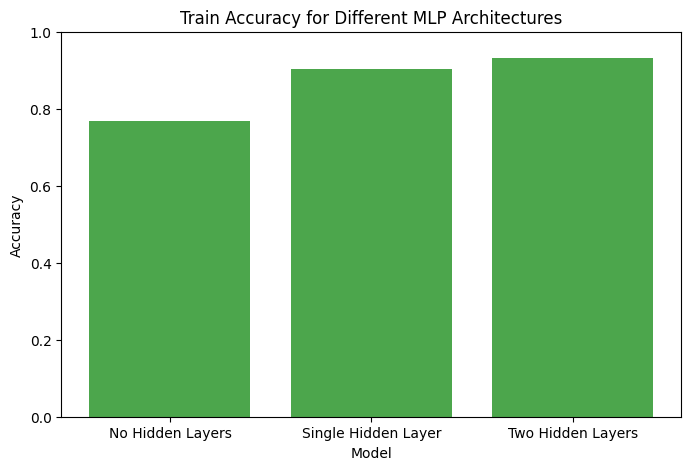

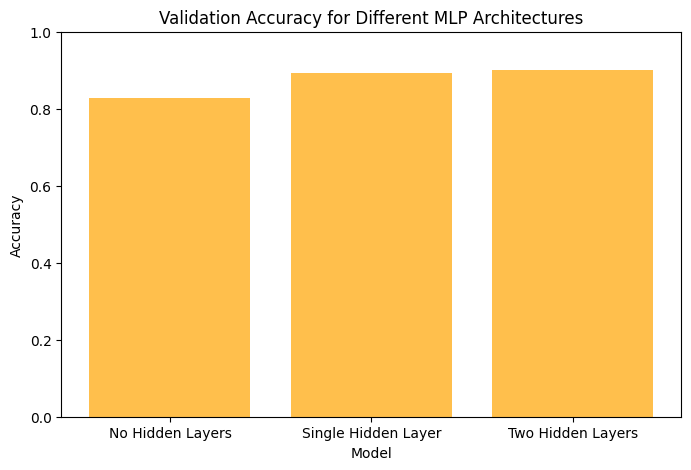

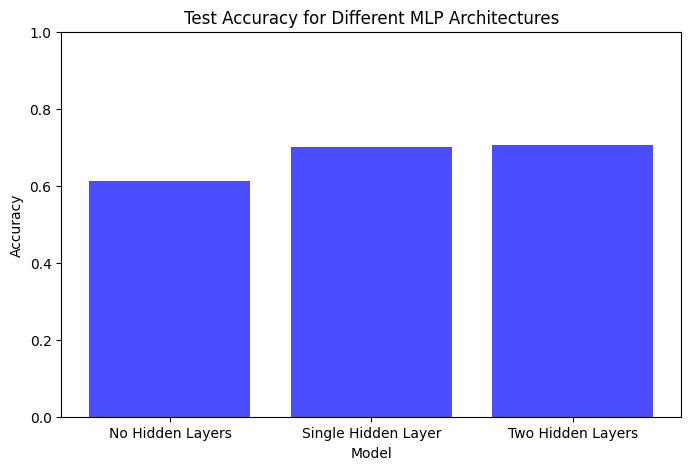

                     Train Accuracy  Validation Accuracy  Test Accuracy
No Hidden Layers           0.769364             0.828378       0.612555
Single Hidden Layer        0.902810             0.892158       0.699629
Two Hidden Layers          0.931802             0.901402       0.704579


In [ ]:
import pandas as pd

# Separate train, test, and validation accuracies for plotting
train_accuracies = {model: acc[0] for model, acc in results.items()}
val_accuracies = {model: acc[1] for model, acc in results.items()}
test_accuracies = {model: acc[2] for model, acc in results.items()}

# Plot Train Accuracy
plt.figure(figsize=(8, 5))
plt.bar(train_accuracies.keys(), train_accuracies.values(), color='green', alpha=0.7)
plt.title("Train Accuracy for Different MLP Architectures")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

# Plot Validation Accuracy
plt.figure(figsize=(8, 5))
plt.bar(val_accuracies.keys(), val_accuracies.values(), color='orange', alpha=0.7)
plt.title("Validation Accuracy for Different MLP Architectures")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

# Plot Test Accuracy
plt.figure(figsize=(8, 5))
plt.bar(test_accuracies.keys(), test_accuracies.values(), color='blue', alpha=0.7)
plt.title("Test Accuracy for Different MLP Architectures")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

# Print results in table format
plo

([<matplotlib.axis.XTick at 0x7b320254f100>,
 [Text(0.3, 0, 'No Hidden Layers'),
  Text(1.3, 0, 'Single Hidden Layer'),
  Text(2.3, 0, 'Two Hidden Layers')])

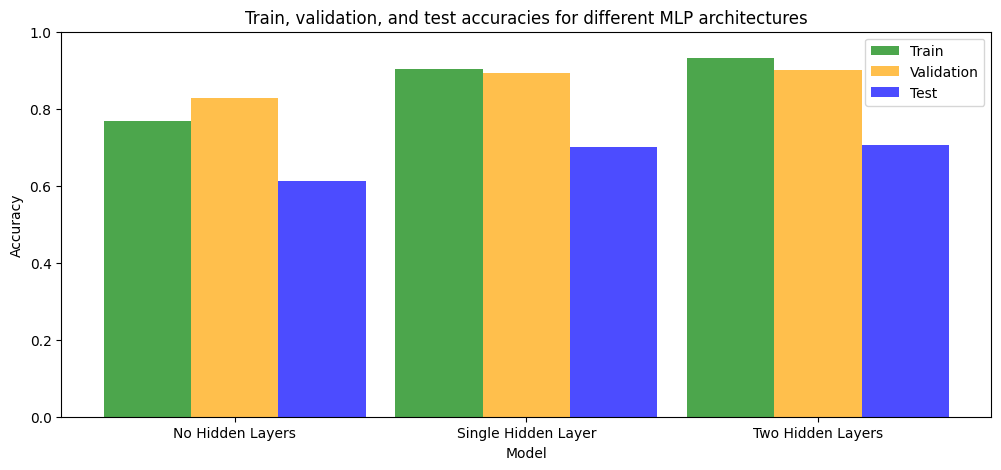

In [ ]:
# Plot accuracies

ind = np.arange(3)
plt.figure(figsize=(12,5))
width = 0.3

# Plotting
plt.bar(ind, train_accuracies.values(), width, color='green', alpha=0.7, label='Train')
plt.bar(ind + width, val_accuracies.values(), width, color='orange', alpha=0.7, label='Validation')
plt.bar(ind + 2*width, test_accuracies.values(), width, color='blue', alpha=0.7, label='Test')

plt.title("Train, validation, and test accuracies for different MLP architectures")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.legend(loc='best')
plt.ylim(0, 1)

plt.xticks(ind + width, train_accuracies.keys())

##### Loss

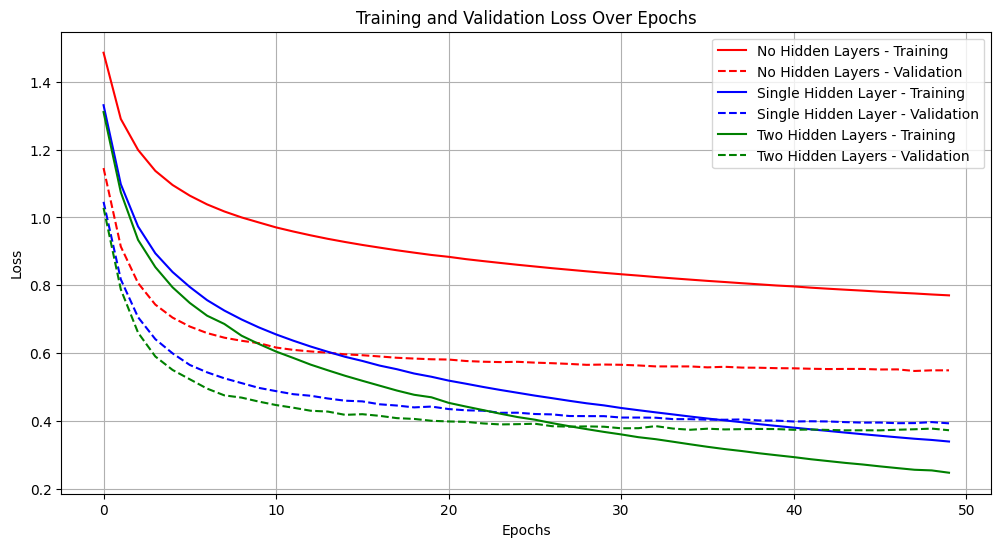

In [ ]:
labels = ["No Hidden Layers", "Single Hidden Layer", "Two Hidden Layers"]

# Plot the loss curves
plot_loss_curves(models_3_1, labels)

#### Grid search (lr, leaky ReLU alpha)

In [ ]:
def lr_tanh_relu_grid_search(activation_func, lr_list, X_train, y_train, X_val, y_val, X_test=None, y_test=None,
                             num_iter=50, batch_size=64, leaky_alphas=None):
    if activation_func == 'tanh':
        mode = 'tanh'
    elif activation_func == 'leaky_relu':
        mode = 'Leaky ReLU'
        if leaky_alphas == None:
            raise ValueError("leaky_alphas cannot be None for Leaky ReLU activation function.")
    else:
        raise ValueError("Invalid activation function. Use 'tanh' or 'leaky_relu'.")

    model_dict = {}
    train_accuracy_dict = {}
    val_accuracy_dict = {}

    print(f"Performing grid search over lr for model with 2 hidden layers, {mode} activation")
    for lr in lr_list:
        print(f"\n----------------Learning rate={lr}----------------")

        if activation_func == 'tanh':
            model = MLP(
                activation_function=activation_func,
                num_hidden_layers=2,
                hidden_units=[256, 256],
                input_dim=X_train.shape[1],
                output_dim=11,
                learning_rate=lr
            )

            train_acc, val_acc, _ = run_experiment(model, X_train, y_train, X_val, y_val, X_test, y_test,
                                                  num_iterations=num_iter, batch_size=batch_size, print_test=False)
            model_dict[lr] = model
            train_accuracy_dict[lr] = train_acc
            val_accuracy_dict[lr] = val_acc

            fobj = open(f'drive/MyDrive/COMP551_A3/3.2_lr_{lr}_model_{activation_func}.pkl', 'wb')
            pickle.dump(model, fobj)
            fobj.close()

            fobj = open(f'drive/MyDrive/COMP551_A3/3.2_lr_{lr}_train_acc_{activation_func}.pkl', 'wb')
            pickle.dump(train_acc, fobj)
            fobj.close()

            fobj = open(f'drive/MyDrive/COMP551_A3/3.2_lr_{lr}_val_acc_{activation_func}.pkl', 'wb')
            pickle.dump(val_acc, fobj)
            fobj.close()

        else:
            for alpha in leaky_alphas:
                print(f"\nTraining with Learning Rate: {lr}, Leaky ReLU Alpha: {alpha}")

                model = MLP(
                    activation_function=activation_func,
                    num_hidden_layers=2,
                    hidden_units=[256, 256],
                    input_dim=X_train.shape[1],
                    output_dim=11,
                    learning_rate=lr,
                    leaky_alpha=alpha
                )

                train_acc, val_acc, _ = run_experiment(model, X_train, y_train, X_val, y_val, X_test, y_test,
                                                      num_iterations=num_iter, batch_size=batch_size, print_test=False)
                model_dict[(lr, alpha)] = model
                train_accuracy_dict[(lr, alpha)] = train_acc
                val_accuracy_dict[(lr, alpha)] = val_acc

                fobj = open(f'drive/MyDrive/COMP551_A3/3.2_lr_{lr}_model_{activation_func}_alpha_{alpha}.pkl', 'wb')
                pickle.dump(model, fobj)
                fobj.close()

                fobj = open(f'drive/MyDrive/COMP551_A3/3.2_lr_{lr}_train_acc_{activation_func}_alpha_{alpha}.pkl', 'wb')
                pickle.dump(train_acc, fobj)
                fobj.close()

                fobj = open(f'drive/MyDrive/COMP551_A3/3.2_lr_{lr}_val_acc_{activation_func}_alpha_{alpha}.pkl', 'wb')
                pickle.dump(val_acc, fobj)
                fobj.close()

    fobj = open(f'drive/MyDrive/COMP551_A3/3.2_all_models_{activation_func}.pkl', 'wb')
    pickle.dump(model_dict, fobj)
    fobj.close()

    fobj = open(f'drive/MyDrive/COMP551_A3/3.2_train_accuracies_{activation_func}.pkl', 'wb')
    pickle.dump(train_accuracy_dict, fobj)
    fobj.close()

    fobj = open(f'drive/MyDrive/COMP551_A3/3.2_val_accuracies_{activation_func}.pkl', 'wb')
    pickle.dump(val_accuracy_dict, fobj)
    fobj.close()

    print("")

    return train_accuracy_dict, val_accuracy_dict

##### Tanh

In [ ]:
# Model 1: Two Hidden Layers with Tanh activation
lr_list_3_2 = [0.001, 0.005, 0.01]

start_time = time.time()
tanh_train_acc, tanh_val_acc = lr_tanh_relu_grid_search('tanh', lr_list_3_2, X_train, y_train, X_val, y_val)
end_time = time.time()

Performing grid search over lr for model with 2 hidden layers, tanh activation

----------------Learning rate=0.001----------------
Epoch 1/50, Training loss: 1.4191, Accuracy: 0.5452
Epoch 10/50, Training loss: 0.8363, Accuracy: 0.7511
Epoch 20/50, Training loss: 0.6826, Accuracy: 0.8012
Epoch 30/50, Training loss: 0.5785, Accuracy: 0.8347
Epoch 40/50, Training loss: 0.4977, Accuracy: 0.8607
Epoch 50/50, Training loss: 0.4314, Accuracy: 0.8829
Train Accuracy: 0.8829
Validation Accuracy: 0.8874

----------------Learning rate=0.005----------------
Epoch 1/50, Training loss: 0.9841, Accuracy: 0.7019
Epoch 10/50, Training loss: 0.4347, Accuracy: 0.8804
Epoch 20/50, Training loss: 0.2311, Accuracy: 0.9453
Epoch 30/50, Training loss: 0.1310, Accuracy: 0.9759
Epoch 40/50, Training loss: 0.0802, Accuracy: 0.9881
Epoch 50/50, Training loss: 0.0527, Accuracy: 0.9943
Train Accuracy: 0.9943
Validation Accuracy: 0.9020

----------------Learning rate=0.01----------------
Epoch 1/50, Training loss: 

In [ ]:
print(f"Training Time (Tanh grid search): {end_time - start_time:.2f} seconds")

Training Time (Tanh grid search): 2282.63 seconds


The above grid search trained 3 different models in 2282.63 seconds, on CPU. This gives an average of 760.87 seconds per model.

##### Leaky ReLU

In [ ]:
# Model 2: Two Hidden Layers with leaky-relu activation
lr_list_3_2 = [0.001, 0.005, 0.01]
leaky_alphas = [0.01, 0.05, 0.1]

start_time = time.time()
leaky_train_acc, leaky_val_acc = lr_tanh_relu_grid_search('leaky_relu', lr_list_3_2, X_train, y_train, X_val, y_val, leaky_alphas=leaky_alphas)
end_time = time.time()

Performing grid search over lr for model with 2 hidden layers, Leaky ReLU activation

----------------Learning rate=0.001----------------

Training with Learning Rate: 0.001, Leaky ReLU Alpha: 0.01
Epoch 1/50, Training loss: 1.3077, Accuracy: 0.5562
Epoch 10/50, Training loss: 0.6276, Accuracy: 0.7919
Epoch 20/50, Training loss: 0.4709, Accuracy: 0.8498
Epoch 30/50, Training loss: 0.3691, Accuracy: 0.8874
Epoch 40/50, Training loss: 0.3005, Accuracy: 0.9132
Epoch 50/50, Training loss: 0.2489, Accuracy: 0.9312
Train Accuracy: 0.9312
Validation Accuracy: 0.9022

Training with Learning Rate: 0.001, Leaky ReLU Alpha: 0.05
Epoch 1/50, Training loss: 1.2957, Accuracy: 0.5601
Epoch 10/50, Training loss: 0.6299, Accuracy: 0.7909
Epoch 20/50, Training loss: 0.4752, Accuracy: 0.8479
Epoch 30/50, Training loss: 0.3747, Accuracy: 0.8856
Epoch 40/50, Training loss: 0.3067, Accuracy: 0.9104
Epoch 50/50, Training loss: 0.2550, Accuracy: 0.9288
Train Accuracy: 0.9288
Validation Accuracy: 0.9020

Train

In [ ]:
print(f"Training Time (Leaky ReLU grid search): {end_time - start_time:.2f} seconds")

Training Time (Leaky ReLU grid search): 4337.47 seconds


The above grid search trained 9 different models in 4337.47 seconds, on CPU. This gives an average of 481.89 seconds per model.

#### Retrieve best hyperparameters

##### Tanh

In [ ]:
# Load model and accuracy dict (tanh)

fobj = open(f'drive/MyDrive/COMP551_A3/3.2_all_models_tanh.pkl', 'rb')
tanh_model_dict = pickle.load(fobj)
fobj.close()

fobj = open(f'drive/MyDrive/COMP551_A3/3.2_train_accuracies_tanh.pkl', 'rb')
tanh_train_acc = pickle.load(fobj)
fobj.close()

fobj = open(f'drive/MyDrive/COMP551_A3/3.2_val_accuracies_tanh.pkl', 'rb')
tanh_val_acc = pickle.load(fobj)
fobj.close()

In [ ]:
# Retrieve optimal lr for model with 2 hidden layers, based on LOSS

best_tanh_lr = find_optimal_hyperparam_loss(tanh_model_dict)
print(f"Optimal learning rate: {best_tanh_lr}")

Optimal learning rate: 0.005


##### Leaky ReLU

In [ ]:
# Load model and accuracy dict (tanh)

fobj = open(f'drive/MyDrive/COMP551_A3/3.2_all_models_leaky_relu.pkl', 'rb')
leaky_model_dict = pickle.load(fobj)
fobj.close()

fobj = open(f'drive/MyDrive/COMP551_A3/3.2_train_accuracies_leaky_relu.pkl', 'rb')
leaky_train_acc = pickle.load(fobj)
fobj.close()

fobj = open(f'drive/MyDrive/COMP551_A3/3.2_val_accuracies_leaky_relu.pkl', 'rb')
leaky_val_acc = pickle.load(fobj)
fobj.close()

In [ ]:
# Retrieve optimal lr for model with 2 hidden layers, based on LOSS

best_leaky_lr, best_leaky_alpha = find_optimal_hyperparam_loss(leaky_model_dict)
print(f"Optimal learning rate: {best_leaky_lr}")
print(f"Optimal leaky alpha: {best_leaky_alpha}")

Optimal learning rate: 0.001
Optimal leaky alpha: 0.01


#### Plots (against hyperparameters)

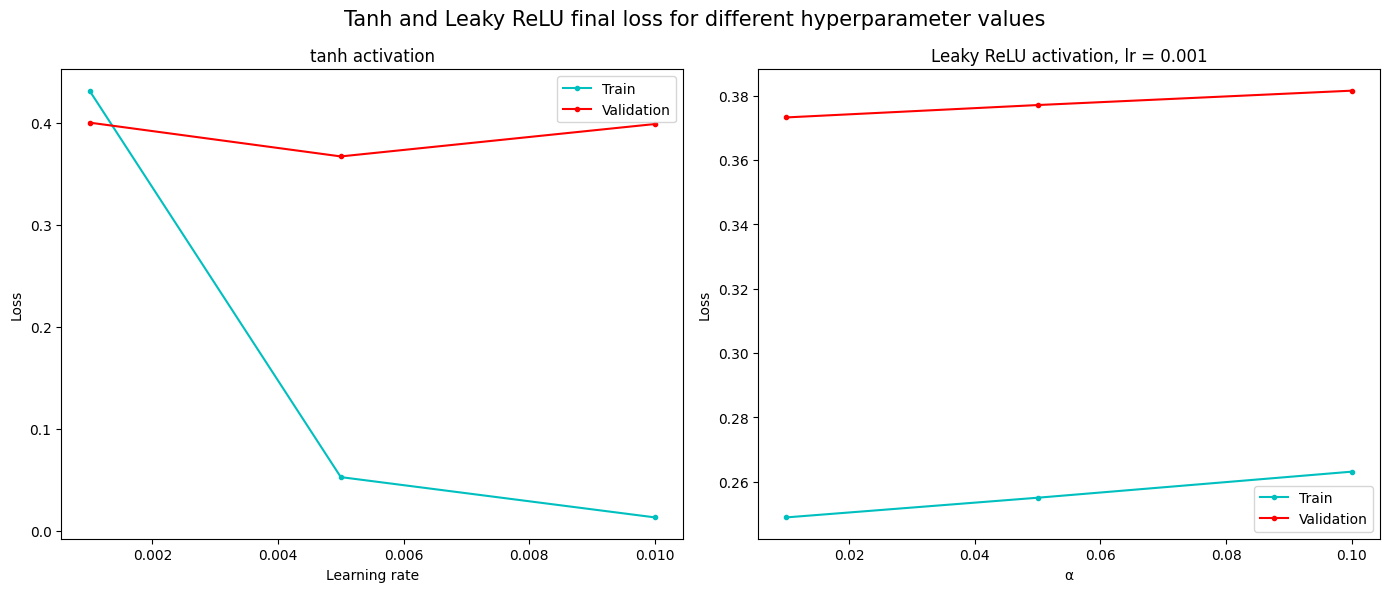

In [ ]:
# Loss plots vs lr/alpha

lr_list_3_2 = [0.001, 0.005, 0.01]
leaky_alphas = [0.01, 0.05, 0.1]

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# Tanh; plot over learning rate
ax = plt.subplot(1, 2, 1)
all_train_loss_tanh = []
all_val_loss_tanh = []

for lr in lr_list_3_2:
    model = tanh_model_dict[lr]
    all_train_loss_tanh.append(model.train_loss_history[-1])
    all_val_loss_tanh.append(model.val_loss_history[-1])

ax.plot(lr_list_3_2, all_train_loss_tanh, 'c.-', label='Train')
ax.plot(lr_list_3_2, all_val_loss_tanh, 'r.-', label='Validation')

ax.set_xlabel("Learning rate")
ax.set_ylabel("Loss")
ax.set_title(f"tanh activation")
ax.legend()


# Leaky ReLU; for the best learning rate, plot over alpha
ax = plt.subplot(1, 2, 2)
all_train_loss_leaky = []
all_val_loss_leaky = []

for alpha in leaky_alphas:
    model = leaky_model_dict[(best_leaky_lr, alpha)]
    all_train_loss_leaky.append(model.train_loss_history[-1])
    all_val_loss_leaky.append(model.val_loss_history[-1])

ax.plot(leaky_alphas, all_train_loss_leaky, 'c.-', label='Train')
ax.plot(leaky_alphas, all_val_loss_leaky, 'r.-', label='Validation')

ax.set_xlabel("α")
ax.set_ylabel("Loss")
ax.set_title(f"Leaky ReLU activation, lr = {best_leaky_lr}")
ax.legend()

fig.suptitle(f"Tanh and Leaky ReLU final loss for different hyperparameter values", fontsize=15)
plt.tight_layout()
plt.show()

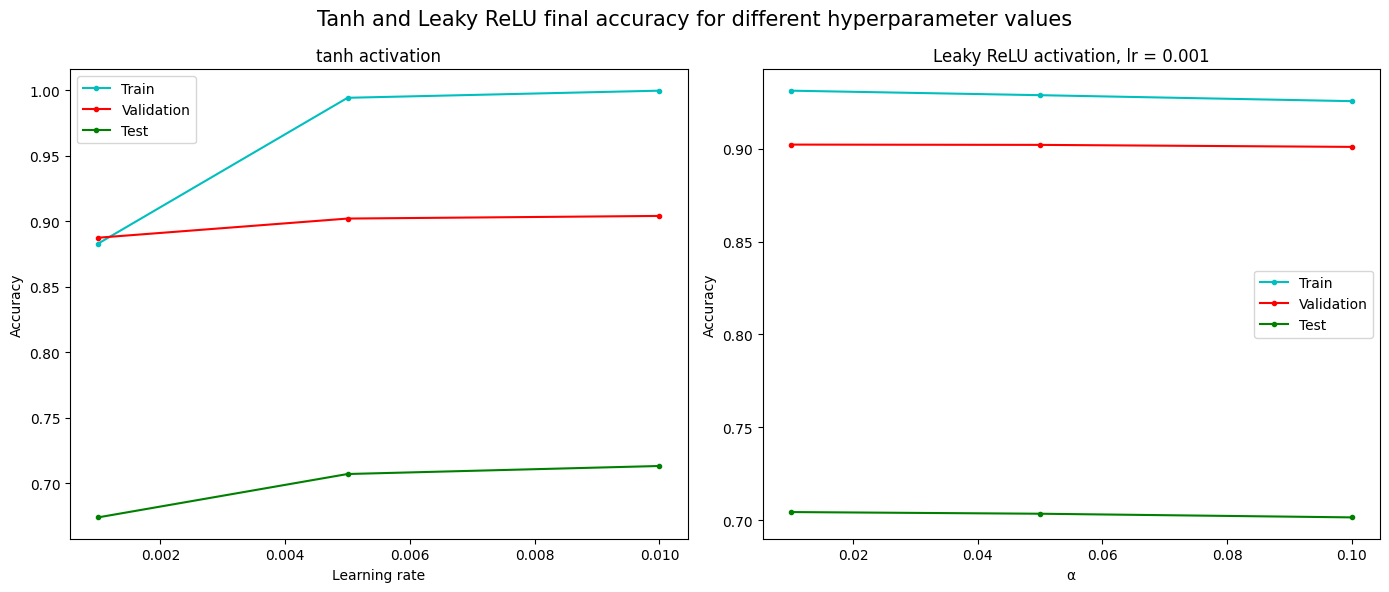

In [ ]:
# Accuracy plots vs lr/alpha

lr_list_3_2 = [0.001, 0.005, 0.01]
leaky_alphas = [0.01, 0.05, 0.1]

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# Tanh; plot over learning rate
ax = plt.subplot(1, 2, 1)
all_train_acc_tanh = []
all_val_acc_tanh = []
all_test_acc_tanh = []

for lr in lr_list_3_2:
    model = tanh_model_dict[lr]
    y_pred_test = model.predict(X_test)
    test_acc = model.evaluate_acc(y_test, y_pred_test)

    all_train_acc_tanh.append(tanh_train_acc[lr])
    all_val_acc_tanh.append(tanh_val_acc[lr])
    all_test_acc_tanh.append(test_acc)

ax.plot(lr_list_3_2, all_train_acc_tanh, 'c.-', label='Train')
ax.plot(lr_list_3_2, all_val_acc_tanh, 'r.-', label='Validation')
ax.plot(lr_list_3_2, all_test_acc_tanh, 'g.-', label='Test')

ax.set_xlabel("Learning rate")
ax.set_ylabel("Accuracy")
ax.set_title(f"tanh activation")
ax.legend()


# Leaky ReLU; for the best learning rate, plot over alpha
ax = plt.subplot(1, 2, 2)
all_train_acc_leaky = []
all_val_acc_leaky = []
all_test_acc_leaky = []

for alpha in leaky_alphas:
    model = leaky_model_dict[(best_leaky_lr, alpha)]
    y_pred_test = model.predict(X_test)
    test_acc = model.evaluate_acc(y_test, y_pred_test)

    all_train_acc_leaky.append(leaky_train_acc[(best_leaky_lr, alpha)])
    all_val_acc_leaky.append(leaky_val_acc[(best_leaky_lr, alpha)])
    all_test_acc_leaky.append(test_acc)

ax.plot(leaky_alphas, all_train_acc_leaky, 'c.-', label='Train')
ax.plot(leaky_alphas, all_val_acc_leaky, 'r.-', label='Validation')
ax.plot(leaky_alphas, all_test_acc_leaky, 'g.-', label='Test')

ax.set_xlabel("α")
ax.set_ylabel("Accuracy")
ax.set_title(f"Leaky ReLU activation, lr = {best_leaky_lr}")
ax.legend()

fig.suptitle(f"Tanh and Leaky ReLU final accuracy for different hyperparameter values", fontsize=15)
plt.tight_layout()
plt.show()

#### Plots (best models)

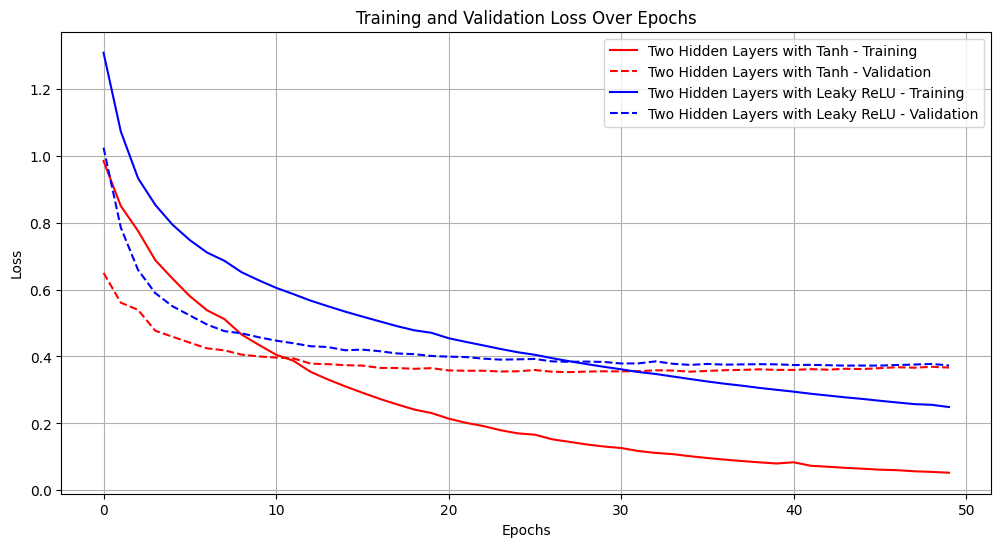

In [ ]:
# Best tanh and leaky ReLU models

best_tanh_model = tanh_model_dict[best_tanh_lr]
best_leaky_model = leaky_model_dict[(best_leaky_lr, best_leaky_alpha)]

models = [best_tanh_model, best_leaky_model]
labels = ["Two Hidden Layers with Tanh", "Two Hidden Layers with Leaky ReLU"]
plot_loss_curves(models, labels)

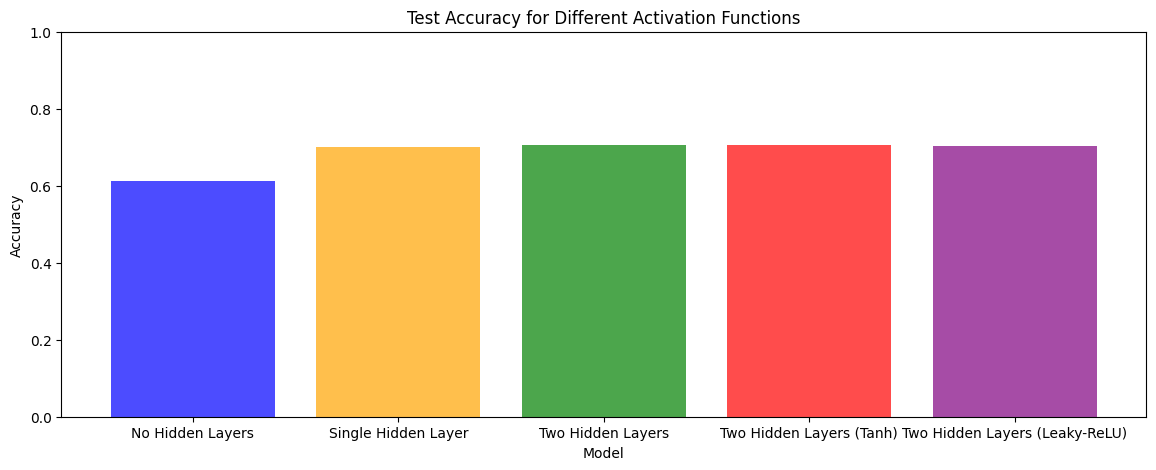


Comparison of Activation Functions (all up until now):
                                Train Accuracy  Validation Accuracy  \
No Hidden Layers                      0.769364             0.828378   
Single Hidden Layer                   0.902810             0.892158   
Two Hidden Layers                     0.931802             0.901402   
Two Hidden Layers (Tanh)              0.994271             0.902018   
Two Hidden Layers (Leaky-ReLU)        0.931194             0.902172   

                                Test Accuracy  
No Hidden Layers                     0.612555  
Single Hidden Layer                  0.699629  
Two Hidden Layers                    0.704579  
Two Hidden Layers (Tanh)             0.706885  
Two Hidden Layers (Leaky-ReLU)       0.704410  


In [ ]:
# Compute test accuracies
y_pred_test_tanh = best_tanh_model.predict(X_test)
accuracy_test_tanh = best_tanh_model.evaluate_acc(y_test, y_pred_test_tanh)

y_pred_test_leaky = best_leaky_model.predict(X_test)
accuracy_test_leaky = best_leaky_model.evaluate_acc(y_test, y_pred_test_leaky)

results["Two Hidden Layers (Tanh)"] = (tanh_train_acc[best_tanh_lr],
                                       tanh_val_acc[best_tanh_lr],
                                       accuracy_test_tanh)
results["Two Hidden Layers (Leaky-ReLU)"] = (leaky_train_acc[(best_leaky_lr, best_leaky_alpha)],
                                             leaky_val_acc[(best_leaky_lr, best_leaky_alpha)],
                                             accuracy_test_leaky
                                             )

# Plot Test Accuracy for all models
test_accuracies = {model: acc[2] for model, acc in results.items()}
plt.figure(figsize=(14, 5))
plt.bar(test_accuracies.keys(), test_accuracies.values(), color=['blue', 'orange', 'green', 'red', 'purple'], alpha=0.7)
plt.title("Test Accuracy for Different Activation Functions")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

# Print results in table format
results_df = pd.DataFrame.from_dict(results, orient='index', columns=["Train Accuracy", "Validation Accuracy", "Test Accuracy"])
print("\nComparison of Activation Functions (all up until now):")
print(results_df)

In [ ]:
# Save results

fobj = open(f'drive/MyDrive/COMP551_A3/3.2_results.pkl', 'wb')
pickle.dump(results, fobj)
fobj.close()

In [ ]:
fobj = open(f'drive/MyDrive/COMP551_A3/3.2_results.pkl', 'rb')
results = pickle.load(fobj)
fobj.close()

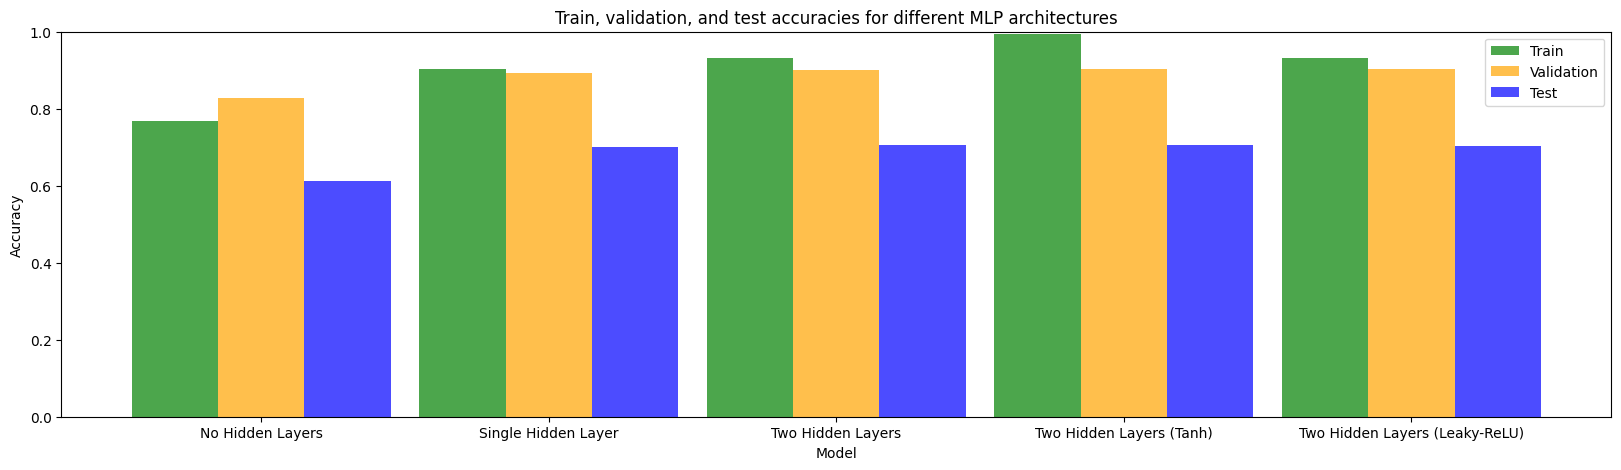

In [ ]:
# Plot accuracies

train_accuracies = {model: acc[0] for model, acc in results.items()}
val_accuracies = {model: acc[1] for model, acc in results.items()}
test_accuracies = {model: acc[2] for model, acc in results.items()}

plt.figure(figsize=(20,5))
ind = np.arange(5)
width = 0.3

# Plotting
plt.bar(ind, train_accuracies.values(), width, color='green', alpha=0.7, label='Train')
plt.bar(ind + width, val_accuracies.values(), width, color='orange', alpha=0.7, label='Validation')
plt.bar(ind + 2*width, test_accuracies.values(), width, color='blue', alpha=0.7, label='Test')

plt.title("Train, validation, and test accuracies for different MLP architectures")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.legend(loc='best')
plt.ylim(0, 1)

plt.xticks(ind + width, train_accuracies.keys())
plt.show()

Available keys in results: dict_keys(['No Hidden Layers', 'Single Hidden Layer', 'Two Hidden Layers', 'Two Hidden Layers (Tanh)', 'Two Hidden Layers (Leaky-ReLU)'])


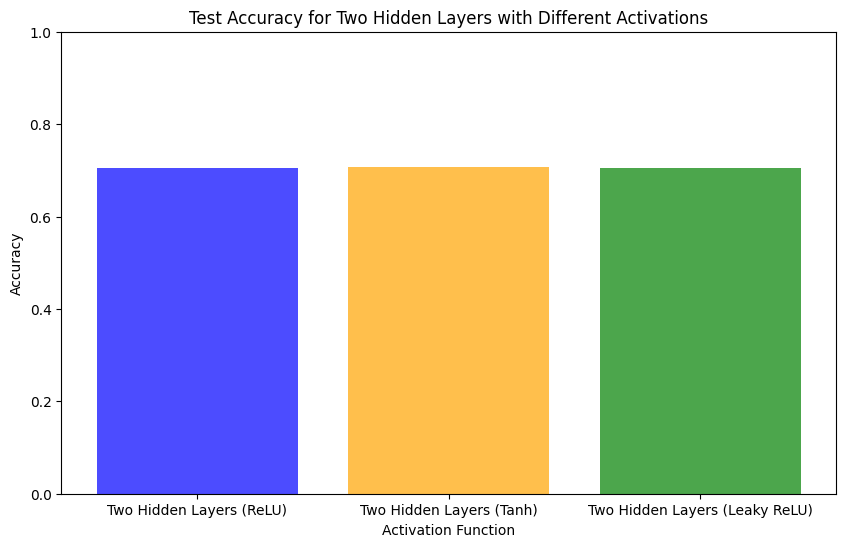

In [ ]:
# Check available keys in results
print("Available keys in results:", results.keys())

# Filter results for models with two hidden layers and different activations
test_accuracies_two_hidden = {
    "Two Hidden Layers (ReLU)": results.get("Two Hidden Layers", [0, 0, 0])[2],
    "Two Hidden Layers (Tanh)": results.get("Two Hidden Layers (Tanh)", [0, 0, 0])[2],
    "Two Hidden Layers (Leaky ReLU)": results.get("Two Hidden Layers (Leaky-ReLU)", [0, 0, 0])[2],
}

# Plot Test Accuracy for two hidden layers with different activations
plt.figure(figsize=(10, 6))
plt.bar(
    test_accuracies_two_hidden.keys(),
    test_accuracies_two_hidden.values(),
    color=['blue', 'orange', 'green'],
    alpha=0.7,
)
plt.title("Test Accuracy for Two Hidden Layers with Different Activations")
plt.xlabel("Activation Function")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()


In [ ]:
all_accuracies_two_hidden = {
    "Two Hidden Layers (ReLU)": results.get("Two Hidden Layers", [0, 0, 0]),
    "Two Hidden Layers (Tanh)": results.get("Two Hidden Layers (Tanh)", [0, 0, 0]),
    "Two Hidden Layers (Leaky ReLU)": results.get("Two Hidden Layers (Leaky-ReLU)", [0, 0, 0]),
}

In [ ]:
# Print results in table format
results_df = pd.DataFrame.from_dict(all_accuracies_two_hidden, orient='index', columns=["Train Accuracy", "Validation Accuracy", "Test Accuracy"])
print("\nComparison of Activation Functions (Two Hidden Layers):")
print(results_df)


Comparison of Activation Functions (Two Hidden Layers):
                                Train Accuracy  Validation Accuracy  \
Two Hidden Layers (ReLU)              0.931802             0.901402   
Two Hidden Layers (Tanh)              0.994271             0.902018   
Two Hidden Layers (Leaky ReLU)        0.931194             0.902172   

                                Test Accuracy  
Two Hidden Layers (ReLU)             0.704579  
Two Hidden Layers (Tanh)             0.706885  
Two Hidden Layers (Leaky ReLU)       0.704410  


#### If we fix the same lr as in 3.1


Training Model with Two Hidden Layers (Tanh Activation)
Epoch 1/50, Training loss: 1.4197, Accuracy: 0.5504
Epoch 10/50, Training loss: 0.8361, Accuracy: 0.7512
Epoch 20/50, Training loss: 0.6814, Accuracy: 0.8006
Epoch 30/50, Training loss: 0.5783, Accuracy: 0.8346
Epoch 40/50, Training loss: 0.4976, Accuracy: 0.8604
Epoch 50/50, Training loss: 0.4311, Accuracy: 0.8826
Train Accuracy: 0.8826
Validation Accuracy: 0.8886
Test Accuracy: 0.6740

Training Model with Two Hidden Layers (Leaky-ReLU Activation)
Epoch 1/50, Training loss: 1.3115, Accuracy: 0.5604
Epoch 10/50, Training loss: 0.6271, Accuracy: 0.7928
Epoch 20/50, Training loss: 0.4675, Accuracy: 0.8497
Epoch 30/50, Training loss: 0.3691, Accuracy: 0.8878
Epoch 40/50, Training loss: 0.3008, Accuracy: 0.9125
Epoch 50/50, Training loss: 0.2488, Accuracy: 0.9316
Train Accuracy: 0.9316
Validation Accuracy: 0.9034
Test Accuracy: 0.7050

ReLU Results already present


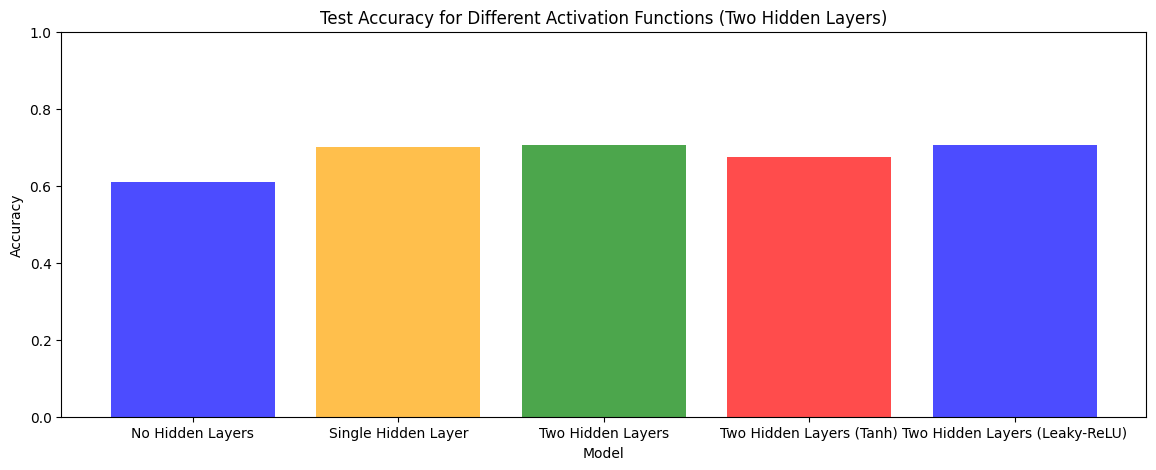


Comparison of Activation Functions (Two Hidden Layers):
                                Train Accuracy  Validation Accuracy  \
No Hidden Layers                      0.768988             0.828994   
Single Hidden Layer                   0.902810             0.892775   
Two Hidden Layers                     0.932062             0.904021   
Two Hidden Layers (Tanh)              0.882584             0.888615   
Two Hidden Layers (Leaky-ReLU)        0.931570             0.903405   

                                Test Accuracy  
No Hidden Layers                     0.610305  
Single Hidden Layer                  0.699348  
Two Hidden Layers                    0.704804  
Two Hidden Layers (Tanh)             0.674035  
Two Hidden Layers (Leaky-ReLU)       0.704972  


In [ ]:
# Define models with different activation functions
# Model 1: Two Hidden Layers with Tanh activation
model_tanh = MLP(
    activation_function='tanh',
    num_hidden_layers=2,
    hidden_units=[256, 256],
    input_dim=X_train.shape[1],
    output_dim=11,
    learning_rate=0.001,
)
print("\nTraining Model with Two Hidden Layers (Tanh Activation)")
results["Two Hidden Layers (Tanh)"] = run_experiment(model_tanh, X_train, y_train, X_val, y_val, X_test, y_test)

# Model 2: Two Hidden Layers with Leaky-ReLU activation
model_leaky_relu = MLP(
    activation_function='leaky_relu',
    num_hidden_layers=2,
    hidden_units=[256, 256],
    input_dim=X_train.shape[1],
    output_dim=11,
    learning_rate=0.001,
)
print("\nTraining Model with Two Hidden Layers (Leaky-ReLU Activation)")
results["Two Hidden Layers (Leaky-ReLU)"] = run_experiment(model_leaky_relu, X_train, y_train, X_val, y_val, X_test, y_test)

# The existing ReLU model (already trained as Model 3)
print("\nReLU Results already present")

# Plot Test Accuracy for all models
test_accuracies = {model: acc[2] for model, acc in results.items()}
plt.figure(figsize=(14, 5))
plt.bar(test_accuracies.keys(), test_accuracies.values(), color=['blue', 'orange', 'green', 'red'], alpha=0.7)
plt.title("Test Accuracy for Different Activation Functions (Two Hidden Layers)")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

# Print results in table format
results_df = pd.DataFrame.from_dict(results, orient='index', columns=["Train Accuracy", "Validation Accuracy", "Test Accuracy"])
print("\nComparison of Activation Functions (Two Hidden Layers):")
print(results_df)


In [ ]:
fobj = open(r"C:\Users\zhouz\Documents\pickle\pickle4.pkl", "wb")
pickle.dump(model_tanh, fobj)
fobj.close()

fobj = open(r"C:\Users\zhouz\Documents\pickle\pickle5.pkl", "wb")
pickle.dump(model_leaky_relu, fobj)
fobj.close()

Available keys in results: dict_keys(['No Hidden Layers', 'Single Hidden Layer', 'Two Hidden Layers', 'Two Hidden Layers (Tanh)', 'Two Hidden Layers (Leaky-ReLU)'])


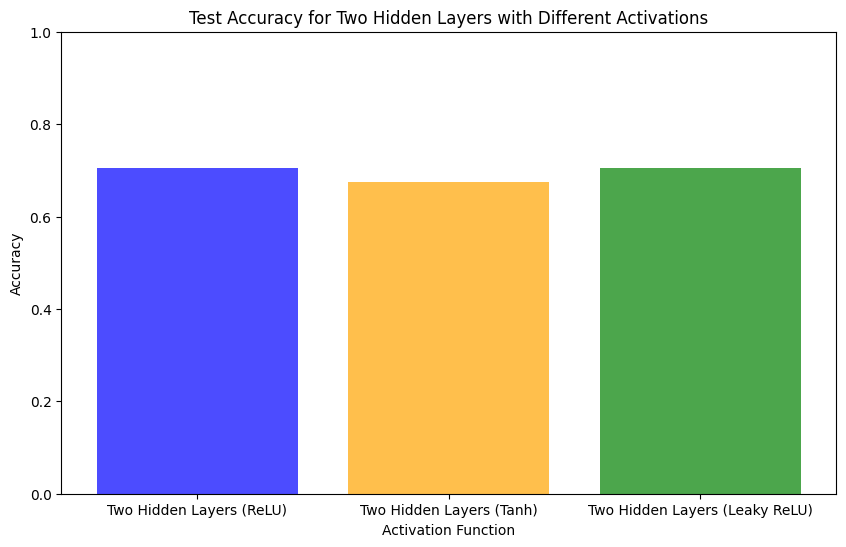

In [ ]:
# Check available keys in results
print("Available keys in results:", results.keys())

# Filter results for models with two hidden layers and different activations
test_accuracies_two_hidden = {
    "Two Hidden Layers (ReLU)": results.get("Two Hidden Layers", [0, 0, 0])[2],
    "Two Hidden Layers (Tanh)": results.get("Two Hidden Layers (Tanh)", [0, 0, 0])[2],
    "Two Hidden Layers (Leaky ReLU)": results.get("Two Hidden Layers (Leaky-ReLU)", [0, 0, 0])[2],
}

# Plot Test Accuracy for two hidden layers with different activations
plt.figure(figsize=(10, 6))
plt.bar(
    test_accuracies_two_hidden.keys(),
    test_accuracies_two_hidden.values(),
    color=['blue', 'orange', 'green'],
    alpha=0.7,
)
plt.title("Test Accuracy for Two Hidden Layers with Different Activations")
plt.xlabel("Activation Function")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()


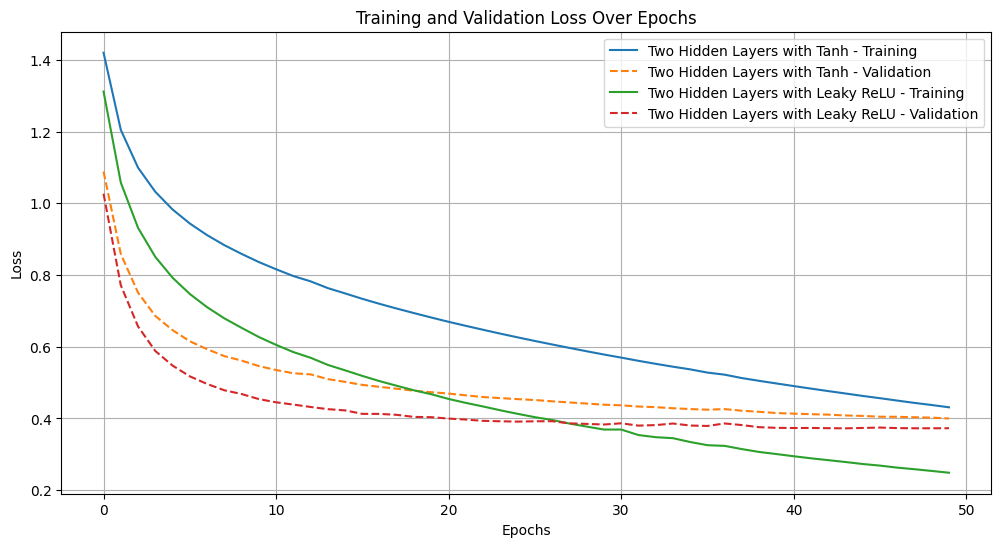

In [ ]:
# List of models and their labels
models = [model_tanh, model_leaky_relu]
labels = ["Two Hidden Layers with Tanh", "Two Hidden Layers with Leaky ReLU"]

plot_loss_curves(models, labels)

#### Grid search (lr, lambda)

In [ ]:
# Define grid search
def reg_lr_grid_search(reg_list, reg_type, lr_list, X_train, y_train, X_val, y_val, X_test=None, y_test=None, batch_size=64):

    if reg_type not in ['L1', 'L2']:
        raise ValueError("Invalid regularization type. Use 'L1' or 'L2'.")

    model_dict = {}
    accuracy_dict = {}

    for lr in lr_list:
        print(f"\n----------------Learning rate={lr}----------------")

        for reg_strength in reg_list:
            print(f"Training with Learning Rate: {lr}, Regularization Strength: {reg_strength}")
            model = MLP(
                activation_function='relu',
                num_hidden_layers=2,
                hidden_units=[256, 256],
                input_dim=X_train.shape[1],
                output_dim=11,
                learning_rate=lr,
                reg_type=reg_type,
                reg_strength=reg_strength
            )

            curr_accuracies = run_experiment(model, X_train, y_train, X_val, y_val, X_test, y_test, num_iterations=50, batch_size=batch_size, print_test=False)
            model_dict[(lr, reg_strength)] = model
            accuracy_dict[(lr, reg_strength)] = curr_accuracies

            fobj = open(f'drive/MyDrive/COMP551_A3/3.3_lr_{lr}_reg_{reg_type}_lamdba_{reg_strength}_model.pkl', 'wb')
            pickle.dump(model, fobj)
            fobj.close()

            fobj = open(f'drive/MyDrive/COMP551_A3/3.3_lr_{lr}_reg_{reg_type}_lamdba_{reg_strength}_accuracies.pkl', 'wb')
            pickle.dump(curr_accuracies, fobj)
            fobj.close()

        print("")

    return model_dict, accuracy_dict

In [ ]:
# Define and evaluate the models, while performing grid search
reg_list = [0.00001, 0.0001, 0.001, 0.01]
lr_list_3_3 = [0.001, 0.005, 0.01]

#### L1 regularization: Two Hidden Layers, ReLu (256 units each)
print("\nTraining L1 Regularization: Two Hidden Layers, ReLu (256 units each)")
l1_all_models, l1_all_accuracies = reg_lr_grid_search(reg_list, 'L1', lr_list_3_3, X_train, y_train, X_val, y_val, X_test, y_test)

# Save models and accuracies
fobj = open(f'drive/MyDrive/COMP551_A3/3.3_l1_all_models.pkl', 'wb')
pickle.dump(l1_all_models, fobj)
fobj.close()

fobj = open(f'drive/MyDrive/COMP551_A3/3.3_l1_all_accuracies.pkl', 'wb')
pickle.dump(l1_all_accuracies, fobj)
fobj.close()


Training L1 Regularization: Two Hidden Layers, ReLu (256 units each)

----------------Learning rate=0.001----------------
Training with Learning Rate: 0.001, Regularization Strength: 1e-05
Epoch 1/50, Training loss: 1.3106, Accuracy: 0.5547
Epoch 10/50, Training loss: 0.6269, Accuracy: 0.7920
Epoch 20/50, Training loss: 0.4697, Accuracy: 0.8497
Epoch 30/50, Training loss: 0.3677, Accuracy: 0.8878
Epoch 40/50, Training loss: 0.2990, Accuracy: 0.9134
Epoch 50/50, Training loss: 0.2474, Accuracy: 0.9318
Train Accuracy: 0.9318
Validation Accuracy: 0.9016
Training with Learning Rate: 0.001, Regularization Strength: 0.0001
Epoch 1/50, Training loss: 1.3106, Accuracy: 0.5547
Epoch 10/50, Training loss: 0.6270, Accuracy: 0.7920
Epoch 20/50, Training loss: 0.4698, Accuracy: 0.8498
Epoch 30/50, Training loss: 0.3678, Accuracy: 0.8879
Epoch 40/50, Training loss: 0.2991, Accuracy: 0.9134
Epoch 50/50, Training loss: 0.2475, Accuracy: 0.9316
Train Accuracy: 0.9316
Validation Accuracy: 0.9017
Traini

In [ ]:
reg_list = [0.00001, 0.0001, 0.001, 0.01]
lr_list_3_3 = [0.001, 0.005, 0.01]

#### L2 regularization: Two Hidden Layers, ReLu (256 units each)
print("\nTraining L2 Regularization: Two Hidden Layers, ReLu (256 units each)")
l2_all_models, l2_all_accuracies = reg_lr_grid_search(reg_list, 'L2', lr_list_3_3, X_train, y_train, X_val, y_val, X_test, y_test)

# Save models and accuracies
fobj = open(f'drive/MyDrive/COMP551_A3/3.3_l2_all_models.pkl', 'wb')
pickle.dump(l2_all_models, fobj)
fobj.close()

fobj = open(f'drive/MyDrive/COMP551_A3/3.3_l2_all_accuracies.pkl', 'wb')
pickle.dump(l2_all_accuracies, fobj)
fobj.close()


Training L2 Regularization: Two Hidden Layers, ReLu (256 units each)

----------------Learning rate=0.001----------------
Training with Learning Rate: 0.001, Regularization Strength: 1e-05
Epoch 1/50, Training loss: 1.3106, Accuracy: 0.5547
Epoch 10/50, Training loss: 0.6269, Accuracy: 0.7920
Epoch 20/50, Training loss: 0.4697, Accuracy: 0.8498
Epoch 30/50, Training loss: 0.3677, Accuracy: 0.8879
Epoch 40/50, Training loss: 0.2989, Accuracy: 0.9135
Epoch 50/50, Training loss: 0.2474, Accuracy: 0.9320
Train Accuracy: 0.9320
Validation Accuracy: 0.9016
Training with Learning Rate: 0.001, Regularization Strength: 0.0001
Epoch 1/50, Training loss: 1.3106, Accuracy: 0.5547
Epoch 10/50, Training loss: 0.6269, Accuracy: 0.7920
Epoch 20/50, Training loss: 0.4697, Accuracy: 0.8499
Epoch 30/50, Training loss: 0.3677, Accuracy: 0.8879
Epoch 40/50, Training loss: 0.2989, Accuracy: 0.9134
Epoch 50/50, Training loss: 0.2474, Accuracy: 0.9318
Train Accuracy: 0.9318
Validation Accuracy: 0.9016
Traini

##### Preliminary plots

In [ ]:
# Load models and accuracies
fobj = open(f'drive/MyDrive/COMP551_A3/3.3_l1_all_models.pkl', 'rb')
l1_all_models = pickle.load(fobj)
fobj.close()

fobj = open(f'drive/MyDrive/COMP551_A3/3.3_l1_all_accuracies.pkl', 'rb')
l1_all_accuracies = pickle.load(fobj)
fobj.close()

fobj = open(f'drive/MyDrive/COMP551_A3/3.3_l2_all_models.pkl', 'rb')
l2_all_models = pickle.load(fobj)
fobj.close()

fobj = open(f'drive/MyDrive/COMP551_A3/3.3_l2_all_accuracies.pkl', 'rb')
l2_all_accuracies = pickle.load(fobj)
fobj.close()

In [ ]:
# Optimal hyperparameters based on loss

# L1 regularization, best hyperparameters
print("L1 regularization")
lasso_best_lr_3_3_loss, lasso_reg_3_3_loss = find_optimal_hyperparam_loss(l1_all_models)
print(f"Optimal learning rate: {lasso_best_lr_3_3_loss}")
print(f"Optimal regularization strength: {lasso_reg_3_3_loss}")

# L2 regularization, best hyperparameters
print("\nL2 regularization")
ridge_best_lr_3_3_loss, ridge_reg_3_3_loss = find_optimal_hyperparam_loss(l2_all_models)
print(f"Optimal learning rate: {ridge_best_lr_3_3_loss}")
print(f"Optimal regularization strength: {ridge_reg_3_3_loss}")

L1 regularization
Optimal learning rate: 0.01
Optimal regularization strength: 0.01

L2 regularization
Optimal learning rate: 0.001
Optimal regularization strength: 0.01


In [ ]:
# Optimal hyperparameters based on accuracy

# L1 regularization, best hyperparameters
print("L1 regularization")
lasso_best_lr_3_3, lasso_reg_3_3 = find_optimal_hyperparam_acc(l1_all_accuracies)
print(f"Optimal learning rate: {lasso_best_lr_3_3}")
print(f"Optimal regularization strength: {lasso_reg_3_3}")

# L2 regularization, best hyperparameters
print("\nL2 regularization")
ridge_best_lr_3_3, ridge_reg_3_3 = find_optimal_hyperparam_acc(l2_all_accuracies)
print(f"Optimal learning rate: {ridge_best_lr_3_3}")
print(f"Optimal regularization strength: {ridge_reg_3_3}")

L1 regularization
Optimal learning rate: 0.01
Optimal regularization strength: 1e-05

L2 regularization
Optimal learning rate: 0.01
Optimal regularization strength: 0.0001


Once again, we note that the hyperparameters that minimize loss are not the same as those that maximize the accuracy!

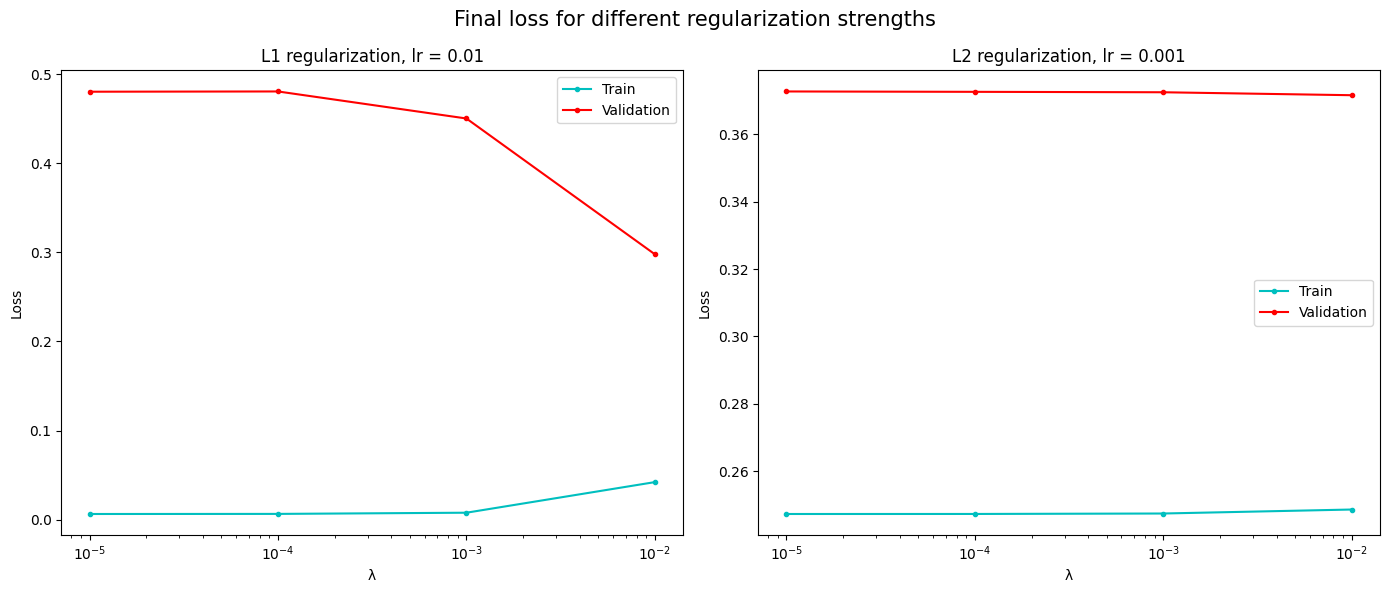

In [ ]:
# Loss plots vs regularization strength

reg_list = [0.00001, 0.0001, 0.001, 0.01]
lr_list_3_3 = [0.001, 0.005, 0.01]


fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# L1 regularization
ax = plt.subplot(1, 2, 1)
all_train_loss_1 = []
all_val_loss_1 = []

for reg_strength in reg_list:
    model = l1_all_models[(lasso_best_lr_3_3_loss, reg_strength)]
    all_train_loss_1.append(model.train_loss_history[-1])
    all_val_loss_1.append(model.val_loss_history[-1])

ax.plot(reg_list, all_train_loss_1, 'c.-', label='Train')
ax.plot(reg_list, all_val_loss_1, 'r.-', label='Validation')

ax.set_xscale("log")
ax.set_xlabel("λ")
ax.set_ylabel("Loss")
ax.set_title(f"L1 regularization, lr = {lasso_best_lr_3_3_loss}")
ax.legend()


# L2 regularization
ax = plt.subplot(1, 2, 2)
all_train_loss_2 = []
all_val_loss_2 = []

for reg_strength in reg_list:
    model = l2_all_models[(ridge_best_lr_3_3_loss, reg_strength)]
    all_train_loss_2.append(model.train_loss_history[-1])
    all_val_loss_2.append(model.val_loss_history[-1])

ax.plot(reg_list, all_train_loss_2, 'c.-', label='Train')
ax.plot(reg_list, all_val_loss_2, 'r.-', label='Validation')

ax.set_xscale("log")
ax.set_xlabel("λ")
ax.set_ylabel("Loss")
ax.set_title(f"L2 regularization, lr = {ridge_best_lr_3_3_loss}")
ax.legend()

fig.suptitle(f"Final loss for different regularization strengths", fontsize=15)
plt.tight_layout()
plt.show()

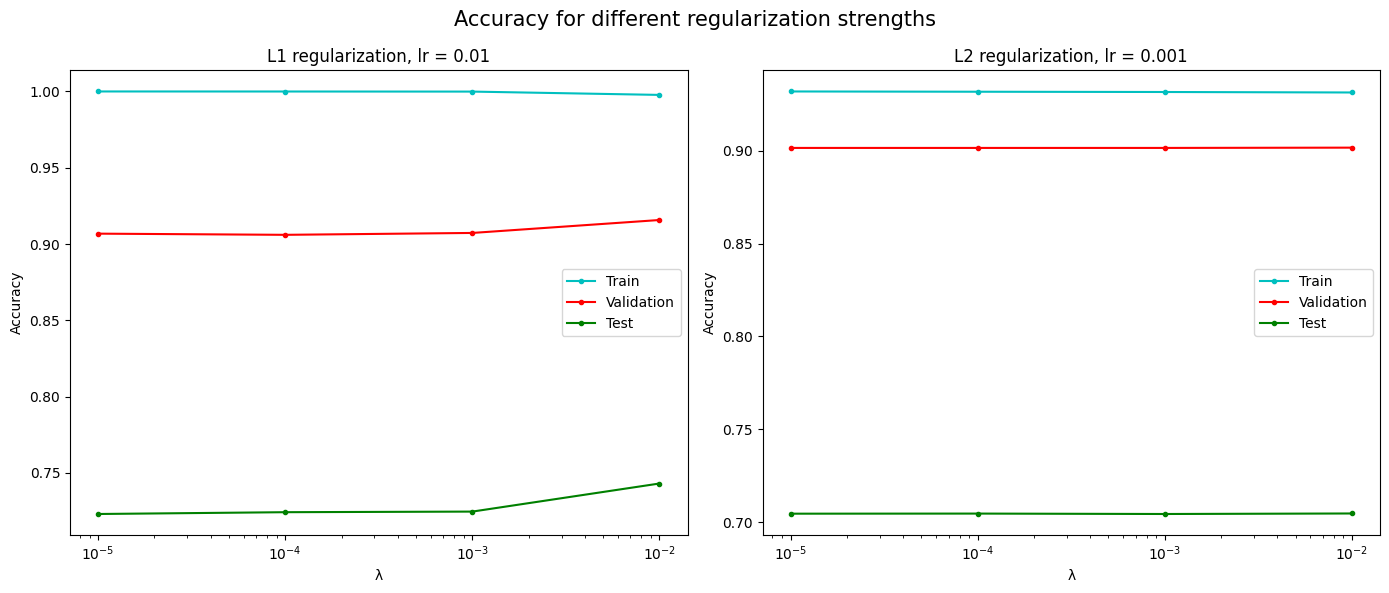

In [ ]:
# Accuracy plots vs regularization strength

reg_list = [0.00001, 0.0001, 0.001, 0.01]
lr_list_3_3 = [0.001, 0.005, 0.01]


fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# L1 regularization
ax = plt.subplot(1, 2, 1)
all_train_acc_1 = []
all_val_acc_1 = []
all_test_acc_1 = []

for reg_strength in reg_list:
    train_acc, val_acc, test_acc = l1_all_accuracies[(lasso_best_lr_3_3_loss, reg_strength)]
    all_train_acc_1.append(train_acc)
    all_val_acc_1.append(val_acc)
    all_test_acc_1.append(test_acc)

ax.plot(reg_list, all_train_acc_1, 'c.-', label='Train')
ax.plot(reg_list, all_val_acc_1, 'r.-', label='Validation')
ax.plot(reg_list, all_test_acc_1, 'g.-', label='Test')

ax.set_xscale("log")
ax.set_xlabel("λ")
ax.set_ylabel("Accuracy")
ax.set_title(f"L1 regularization, lr = {lasso_best_lr_3_3_loss}")
ax.legend()


# L2 regularization
ax = plt.subplot(1, 2, 2)
all_train_acc_2 = []
all_val_acc_2 = []
all_test_acc_2 = []

for reg_strength in reg_list:
    train_acc, val_acc, test_acc = l2_all_accuracies[(ridge_best_lr_3_3_loss, reg_strength)]
    all_train_acc_2.append(train_acc)
    all_val_acc_2.append(val_acc)
    all_test_acc_2.append(test_acc)

ax.plot(reg_list, all_train_acc_2, 'c.-', label='Train')
ax.plot(reg_list, all_val_acc_2, 'r.-', label='Validation')
ax.plot(reg_list, all_test_acc_2, 'g.-', label='Test')

ax.set_xscale("log")
ax.set_xlabel("λ")
ax.set_ylabel("Accuracy")
ax.set_title(f"L2 regularization, lr = {ridge_best_lr_3_3_loss}")
ax.legend()

fig.suptitle(f"Accuracy for different regularization strengths", fontsize=15)
plt.tight_layout()
plt.show()

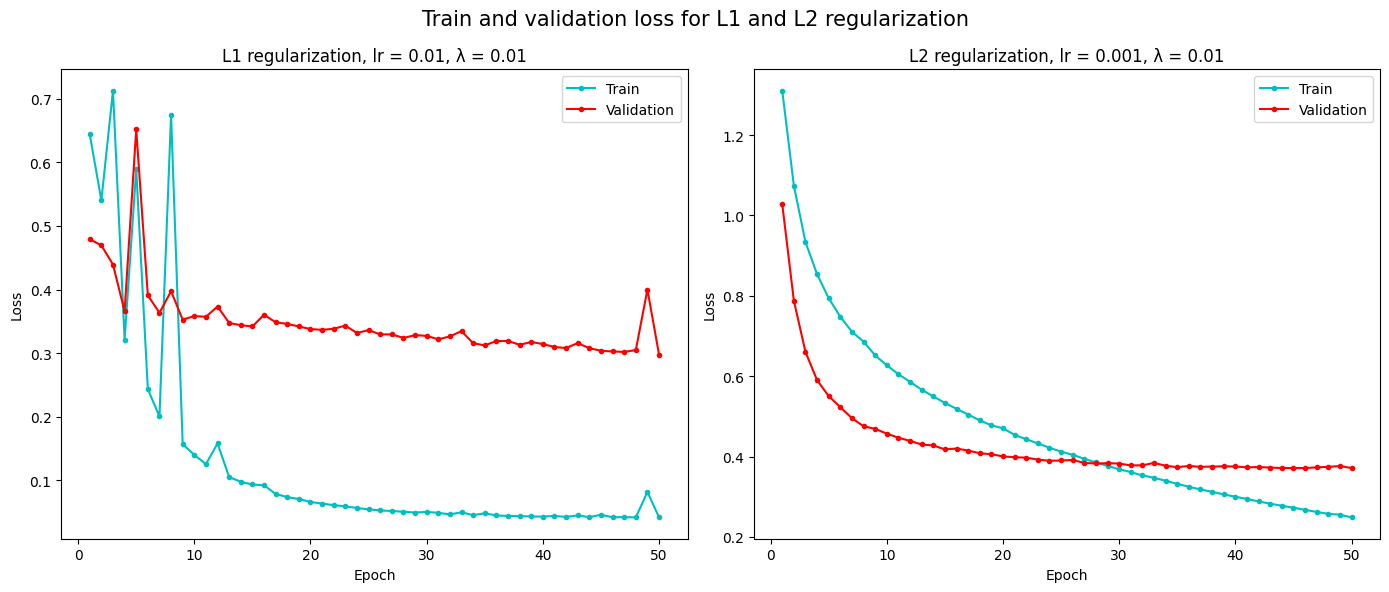

In [ ]:
# Loss vs epoch plots for models with lowest validation error

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))
epoch_list = np.arange(1, 51)

# L1 regularization
ax = plt.subplot(1, 2, 1)
best_lasso_model = l1_all_models_v[(lasso_best_lr_3_3_loss, lasso_reg_3_3_loss)]

ax.plot(epoch_list, best_lasso_model.train_loss_history, 'c.-', label='Train')
ax.plot(epoch_list, best_lasso_model.val_loss_history, 'r.-', label='Validation')

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title(f"L1 regularization, lr = {lasso_best_lr_3_3_loss}, λ = {lasso_reg_3_3_loss}")
ax.legend()

# L2 regularization
ax = plt.subplot(1, 2, 2)
best_ridge_model = l2_all_models_v[(ridge_best_lr_3_3_loss, ridge_reg_3_3_loss)]

ax.plot(epoch_list, best_ridge_model.train_loss_history, 'c.-', label='Train')
ax.plot(epoch_list, best_ridge_model.val_loss_history, 'r.-', label='Validation')

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title(f"L2 regularization, lr = {ridge_best_lr_3_3_loss}, λ = {ridge_reg_3_3_loss}")
ax.legend()

fig.suptitle(f"Train and validation loss for L1 and L2 regularization", fontsize=15)
plt.tight_layout()
plt.show()

#### Second search for lasso

In [ ]:
# Define and evaluate the models, while performing grid search
reg_list_v2 = [0.05, 0.1, 1]
lr_list_3_3_v2 = [0.01]

#### L1 regularization: Two Hidden Layers, ReLu (256 units each)
print("\nTraining L1 Regularization: Two Hidden Layers, ReLu (256 units each)")
l1_all_models_v2, l1_all_accuracies_v2 = reg_lr_grid_search(reg_list_v2, 'L1', lr_list_3_3_v2, X_train, y_train, X_val, y_val, X_test, y_test)

l1_all_models_v2.update(l1_all_models)
l1_all_accuracies_v2.update(l1_all_accuracies)

# Save models and accuracies
fobj = open(f'drive/MyDrive/COMP551_A3/3.3_l1_all_models_v2.pkl', 'wb')
pickle.dump(l1_all_models_v2, fobj)
fobj.close()

fobj = open(f'drive/MyDrive/COMP551_A3/3.3_l1_all_accuracies_v2.pkl', 'wb')
pickle.dump(l1_all_accuracies_v2, fobj)
fobj.close()


Training L1 Regularization: Two Hidden Layers, ReLu (256 units each)

----------------Learning rate=0.01----------------
Training with Learning Rate: 0.01, Regularization Strength: 0.05
Epoch 1/50, Training loss: 0.6650, Accuracy: 0.7775
Epoch 10/50, Training loss: 0.3317, Accuracy: 0.9219
Epoch 20/50, Training loss: 0.7927, Accuracy: 0.7876
Epoch 30/50, Training loss: 0.6110, Accuracy: 0.8215
Epoch 40/50, Training loss: 0.2442, Accuracy: 0.9433
Epoch 50/50, Training loss: 0.2339, Accuracy: 0.9390
Train Accuracy: 0.9390
Validation Accuracy: 0.9150
Training with Learning Rate: 0.01, Regularization Strength: 0.1
Epoch 1/50, Training loss: 0.6985, Accuracy: 0.7678
Epoch 10/50, Training loss: 0.7625, Accuracy: 0.7785
Epoch 20/50, Training loss: 1.0251, Accuracy: 0.6994
Epoch 30/50, Training loss: 0.4708, Accuracy: 0.8629
Epoch 40/50, Training loss: 0.3895, Accuracy: 0.8877
Epoch 50/50, Training loss: 0.4091, Accuracy: 0.8742
Train Accuracy: 0.8742
Validation Accuracy: 0.8989
Training with

##### Updated plots

In [ ]:
# Load models and accuracies
fobj = open(f'drive/MyDrive/COMP551_A3/3.3_l1_all_models_v2.pkl', 'rb')
l1_all_models_v2 = pickle.load(fobj)
fobj.close()

fobj = open(f'drive/MyDrive/COMP551_A3/3.3_l1_all_accuracies_v2.pkl', 'rb')
l1_all_accuracies_v2 = pickle.load(fobj)
fobj.close()

In [ ]:
# Optimal hyperparameters based on loss (updated for lasso)

# L1 regularization, best hyperparameters
print("L1 regularization")
lasso_best_lr_3_3_loss, lasso_reg_3_3_loss = find_optimal_hyperparam_loss(l1_all_models_v2)
print(f"Optimal learning rate: {lasso_best_lr_3_3_loss}")
print(f"Optimal regularization strength: {lasso_reg_3_3_loss}")

# L2 regularization, best hyperparameters
print("\nL2 regularization")
ridge_best_lr_3_3_loss, ridge_reg_3_3_loss = find_optimal_hyperparam_loss(l2_all_models)
print(f"Optimal learning rate: {ridge_best_lr_3_3_loss}")
print(f"Optimal regularization strength: {ridge_reg_3_3_loss}")

L1 regularization
Optimal learning rate: 0.01
Optimal regularization strength: 0.01

L2 regularization
Optimal learning rate: 0.001
Optimal regularization strength: 0.01


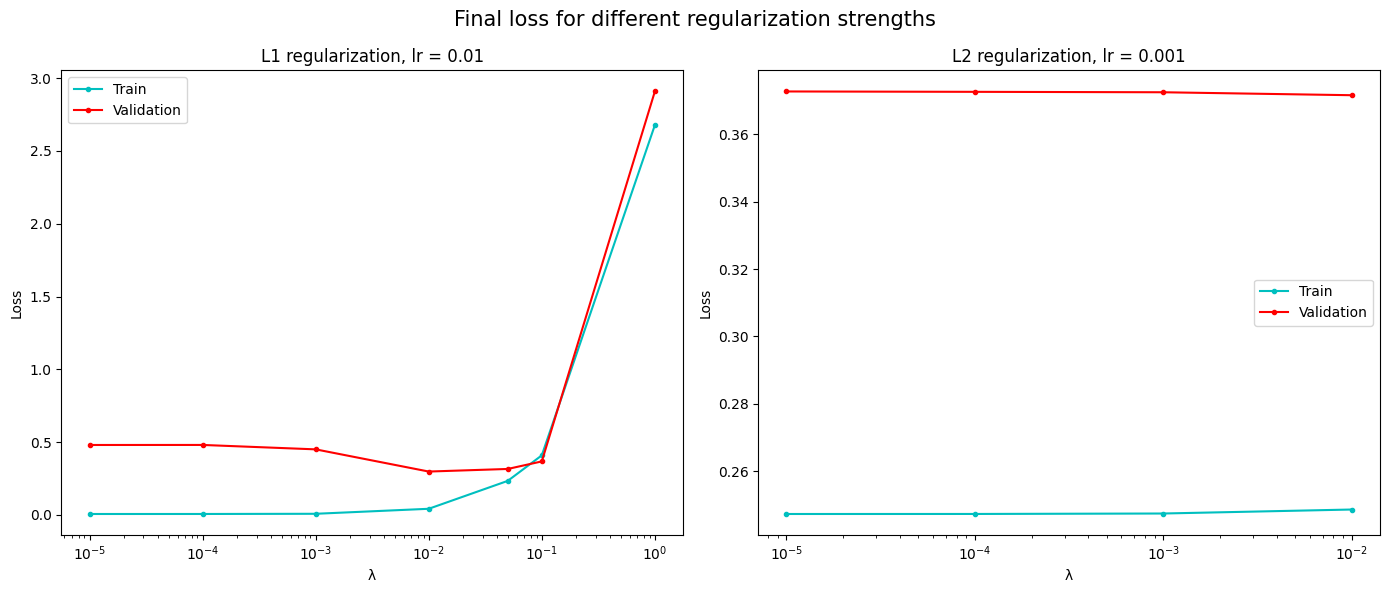

In [ ]:
# Loss plots vs regularization strength

reg_list = [0.00001, 0.0001, 0.001, 0.01]
reg_list_lasso = [0.00001, 0.0001, 0.001, 0.01, 0.05, 0.1, 1]
lr_list_3_3 = [0.001, 0.005, 0.01]


fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# L1 regularization
ax = plt.subplot(1, 2, 1)
all_train_loss_1 = []
all_val_loss_1 = []

for reg_strength in reg_list_lasso:
    model = l1_all_models_v2[(lasso_best_lr_3_3_loss, reg_strength)]
    all_train_loss_1.append(model.train_loss_history[-1])
    all_val_loss_1.append(model.val_loss_history[-1])

ax.plot(reg_list_lasso, all_train_loss_1, 'c.-', label='Train')
ax.plot(reg_list_lasso, all_val_loss_1, 'r.-', label='Validation')

ax.set_xscale("log")
ax.set_xlabel("λ")
ax.set_ylabel("Loss")
ax.set_title(f"L1 regularization, lr = {lasso_best_lr_3_3_loss}")
ax.legend()


# L2 regularization
ax = plt.subplot(1, 2, 2)
all_train_loss_2 = []
all_val_loss_2 = []

for reg_strength in reg_list:
    model = l2_all_models[(ridge_best_lr_3_3_loss, reg_strength)]
    all_train_loss_2.append(model.train_loss_history[-1])
    all_val_loss_2.append(model.val_loss_history[-1])

ax.plot(reg_list, all_train_loss_2, 'c.-', label='Train')
ax.plot(reg_list, all_val_loss_2, 'r.-', label='Validation')

ax.set_xscale("log")
ax.set_xlabel("λ")
ax.set_ylabel("Loss")
ax.set_title(f"L2 regularization, lr = {ridge_best_lr_3_3_loss}")
ax.legend()

fig.suptitle(f"Final loss for different regularization strengths", fontsize=15)
plt.tight_layout()
plt.show()

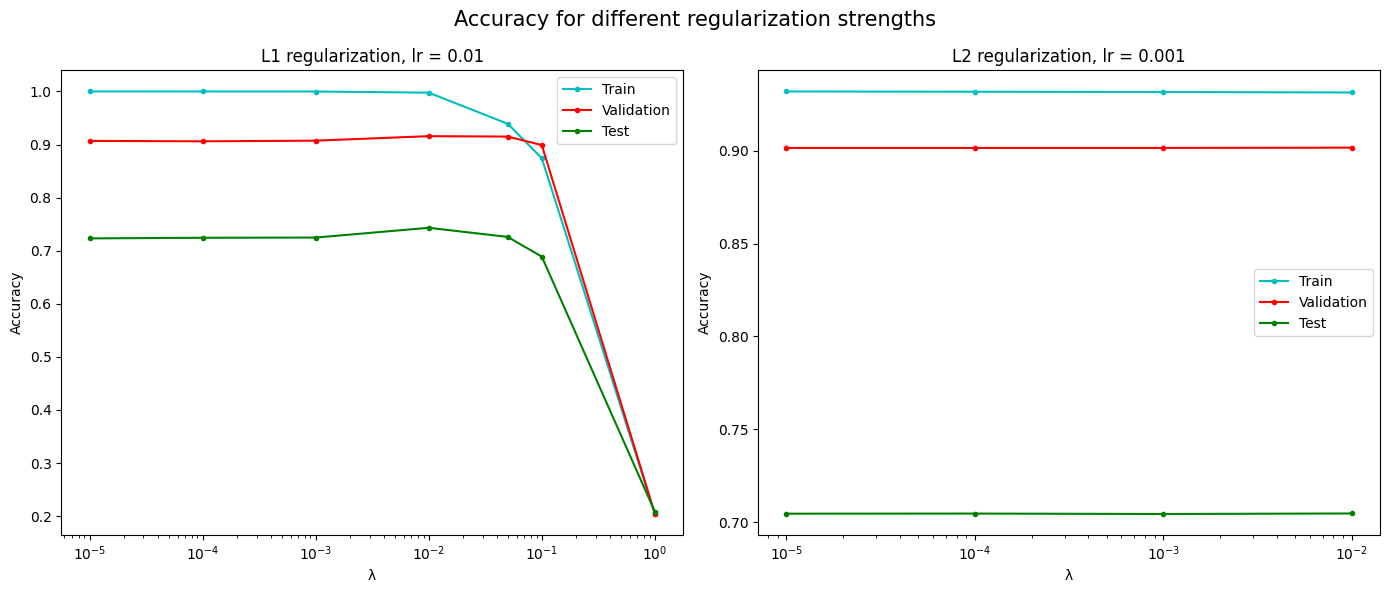

In [ ]:
# Accuracy plots vs regularization strength

reg_list = [0.00001, 0.0001, 0.001, 0.01]
reg_list_lasso = [0.00001, 0.0001, 0.001, 0.01, 0.05, 0.1, 1]
lr_list_3_3 = [0.001, 0.005, 0.01]


fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# L1 regularization
ax = plt.subplot(1, 2, 1)
all_train_acc_1 = []
all_val_acc_1 = []
all_test_acc_1 = []

for reg_strength in reg_list_lasso:
    train_acc, val_acc, test_acc = l1_all_accuracies_v2[(lasso_best_lr_3_3_loss, reg_strength)]
    all_train_acc_1.append(train_acc)
    all_val_acc_1.append(val_acc)
    all_test_acc_1.append(test_acc)

ax.plot(reg_list_lasso, all_train_acc_1, 'c.-', label='Train')
ax.plot(reg_list_lasso, all_val_acc_1, 'r.-', label='Validation')
ax.plot(reg_list_lasso, all_test_acc_1, 'g.-', label='Test')

ax.set_xscale("log")
ax.set_xlabel("λ")
ax.set_ylabel("Accuracy")
ax.set_title(f"L1 regularization, lr = {lasso_best_lr_3_3_loss}")
ax.legend()


# L2 regularization
ax = plt.subplot(1, 2, 2)
all_train_acc_2 = []
all_val_acc_2 = []
all_test_acc_2 = []

for reg_strength in reg_list:
    train_acc, val_acc, test_acc = l2_all_accuracies[(ridge_best_lr_3_3_loss, reg_strength)]
    all_train_acc_2.append(train_acc)
    all_val_acc_2.append(val_acc)
    all_test_acc_2.append(test_acc)

ax.plot(reg_list, all_train_acc_2, 'c.-', label='Train')
ax.plot(reg_list, all_val_acc_2, 'r.-', label='Validation')
ax.plot(reg_list, all_test_acc_2, 'g.-', label='Test')

ax.set_xscale("log")
ax.set_xlabel("λ")
ax.set_ylabel("Accuracy")
ax.set_title(f"L2 regularization, lr = {ridge_best_lr_3_3_loss}")
ax.legend()

fig.suptitle(f"Accuracy for different regularization strengths", fontsize=15)
plt.tight_layout()
plt.show()

#### Second search for ridge

In [ ]:
# Define and evaluate the models, while performing grid search
reg_list_v2 = [0.05, 0.1, 1]
lr_list_3_3_v2 = [0.01]

#### L2 regularization: Two Hidden Layers, ReLu (256 units each)
print("\nTraining L2 Regularization: Two Hidden Layers, ReLu (256 units each)")
l2_all_models_v2, l2_all_accuracies_v2 = reg_lr_grid_search(reg_list_v2, 'L2', lr_list_3_3_v2, X_train, y_train, X_val, y_val, X_test, y_test)

l2_all_models_v2.update(l2_all_models)
l2_all_accuracies_v2.update(l2_all_accuracies)

# Save models and accuracies
fobj = open(f'drive/MyDrive/COMP551_A3/3.3_l2_all_models_v2.pkl', 'wb')
pickle.dump(l2_all_models_v2, fobj)
fobj.close()

fobj = open(f'drive/MyDrive/COMP551_A3/3.3_l2_all_accuracies_v2.pkl', 'wb')
pickle.dump(l2_all_accuracies_v2, fobj)
fobj.close()


Training L2 Regularization: Two Hidden Layers, ReLu (256 units each)

----------------Learning rate=0.01----------------
Training with Learning Rate: 0.01, Regularization Strength: 0.05
Epoch 1/50, Training loss: 0.6419, Accuracy: 0.7830
Epoch 10/50, Training loss: 0.1254, Accuracy: 0.9732
Epoch 20/50, Training loss: 0.0465, Accuracy: 0.9941
Epoch 30/50, Training loss: 0.0274, Accuracy: 0.9974
Epoch 40/50, Training loss: 0.0180, Accuracy: 0.9992
Epoch 50/50, Training loss: 0.0145, Accuracy: 0.9996
Train Accuracy: 0.9996
Validation Accuracy: 0.9123
Training with Learning Rate: 0.01, Regularization Strength: 0.1
Epoch 1/50, Training loss: 0.6434, Accuracy: 0.7824
Epoch 10/50, Training loss: 0.1346, Accuracy: 0.9715
Epoch 20/50, Training loss: 0.0565, Accuracy: 0.9928
Epoch 30/50, Training loss: 0.0378, Accuracy: 0.9965
Epoch 40/50, Training loss: 0.0282, Accuracy: 0.9986
Epoch 50/50, Training loss: 0.0246, Accuracy: 0.9992
Train Accuracy: 0.9992
Validation Accuracy: 0.9165
Training with

##### Updated plots

In [ ]:
# Load models and accuracies
fobj = open(f'drive/MyDrive/COMP551_A3/3.3_l2_all_models_v2.pkl', 'rb')
l2_all_models_v2 = pickle.load(fobj)
fobj.close()

fobj = open(f'drive/MyDrive/COMP551_A3/3.3_l2_all_accuracies_v2.pkl', 'rb')
l2_all_accuracies_v2 = pickle.load(fobj)
fobj.close()

In [ ]:
# Optimal hyperparameters based on loss (updated)

# L1 regularization, best hyperparameters
print("L1 regularization")
lasso_best_lr_3_3_loss, lasso_reg_3_3_loss = find_optimal_hyperparam_loss(l1_all_models_v2)
print(f"Optimal learning rate: {lasso_best_lr_3_3_loss}")
print(f"Optimal regularization strength: {lasso_reg_3_3_loss}")

# L2 regularization, best hyperparameters
print("\nL2 regularization")
ridge_best_lr_3_3_loss, ridge_reg_3_3_loss = find_optimal_hyperparam_loss(l2_all_models_v2)
print(f"Optimal learning rate: {ridge_best_lr_3_3_loss}")
print(f"Optimal regularization strength: {ridge_reg_3_3_loss}")

L1 regularization
Optimal learning rate: 0.01
Optimal regularization strength: 0.01

L2 regularization
Optimal learning rate: 0.01
Optimal regularization strength: 1


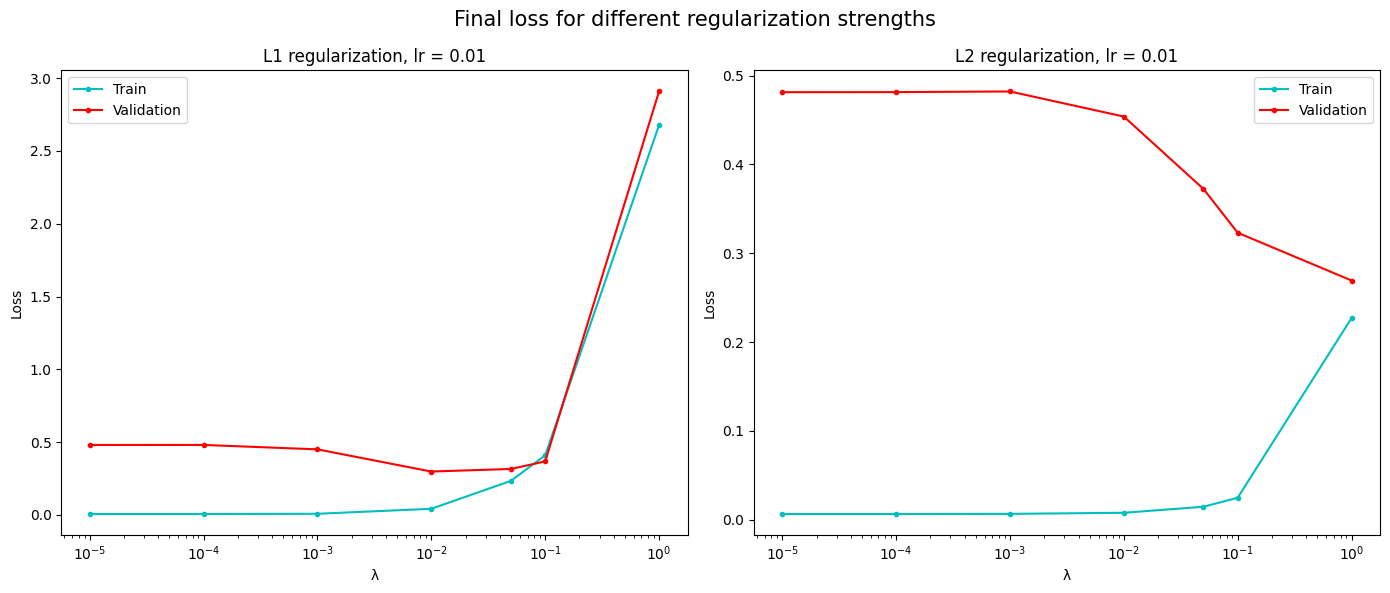

In [ ]:
# Loss plots vs regularization strength

reg_list = [0.00001, 0.0001, 0.001, 0.01, 0.05, 0.1, 1]
lr_list_3_3 = [0.001, 0.005, 0.01]


fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# L1 regularization
ax = plt.subplot(1, 2, 1)
all_train_loss_1 = []
all_val_loss_1 = []

for reg_strength in reg_list:
    model = l1_all_models_v2[(lasso_best_lr_3_3_loss, reg_strength)]
    all_train_loss_1.append(model.train_loss_history[-1])
    all_val_loss_1.append(model.val_loss_history[-1])

ax.plot(reg_list, all_train_loss_1, 'c.-', label='Train')
ax.plot(reg_list, all_val_loss_1, 'r.-', label='Validation')

ax.set_xscale("log")
ax.set_xlabel("λ")
ax.set_ylabel("Loss")
ax.set_title(f"L1 regularization, lr = {lasso_best_lr_3_3_loss}")
ax.legend()


# L2 regularization
ax = plt.subplot(1, 2, 2)
all_train_loss_2 = []
all_val_loss_2 = []

for reg_strength in reg_list:
    model = l2_all_models_v2[(ridge_best_lr_3_3_loss, reg_strength)]
    all_train_loss_2.append(model.train_loss_history[-1])
    all_val_loss_2.append(model.val_loss_history[-1])

ax.plot(reg_list, all_train_loss_2, 'c.-', label='Train')
ax.plot(reg_list, all_val_loss_2, 'r.-', label='Validation')

ax.set_xscale("log")
ax.set_xlabel("λ")
ax.set_ylabel("Loss")
ax.set_title(f"L2 regularization, lr = {ridge_best_lr_3_3_loss}")
ax.legend()

fig.suptitle(f"Final loss for different regularization strengths", fontsize=15)
plt.tight_layout()
plt.show()

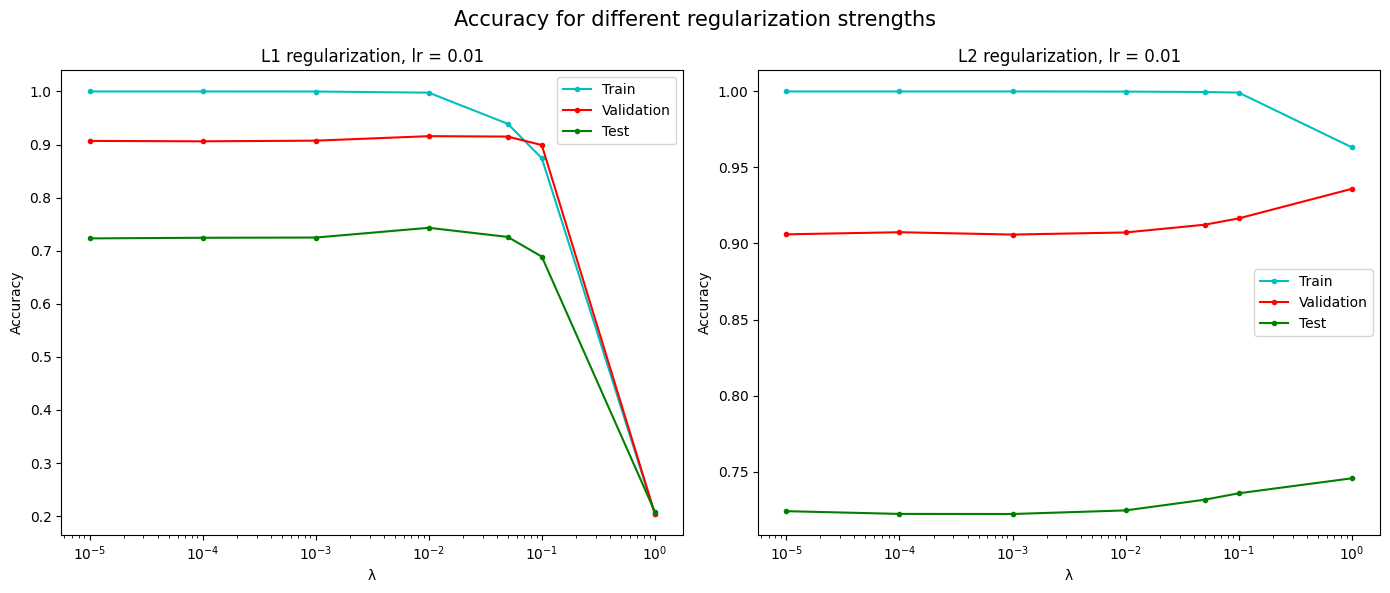

In [ ]:
# Accuracy plots vs regularization strength

reg_list = [0.00001, 0.0001, 0.001, 0.01, 0.05, 0.1, 1]
lr_list_3_3 = [0.001, 0.005, 0.01]


fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# L1 regularization
ax = plt.subplot(1, 2, 1)
all_train_acc_1 = []
all_val_acc_1 = []
all_test_acc_1 = []

for reg_strength in reg_list:
    train_acc, val_acc, test_acc = l1_all_accuracies_v2[(lasso_best_lr_3_3_loss, reg_strength)]
    all_train_acc_1.append(train_acc)
    all_val_acc_1.append(val_acc)
    all_test_acc_1.append(test_acc)

ax.plot(reg_list, all_train_acc_1, 'c.-', label='Train')
ax.plot(reg_list, all_val_acc_1, 'r.-', label='Validation')
ax.plot(reg_list, all_test_acc_1, 'g.-', label='Test')

ax.set_xscale("log")
ax.set_xlabel("λ")
ax.set_ylabel("Accuracy")
ax.set_title(f"L1 regularization, lr = {lasso_best_lr_3_3_loss}")
ax.legend()


# L2 regularization
ax = plt.subplot(1, 2, 2)
all_train_acc_2 = []
all_val_acc_2 = []
all_test_acc_2 = []

for reg_strength in reg_list:
    train_acc, val_acc, test_acc = l2_all_accuracies_v2[(ridge_best_lr_3_3_loss, reg_strength)]
    all_train_acc_2.append(train_acc)
    all_val_acc_2.append(val_acc)
    all_test_acc_2.append(test_acc)

ax.plot(reg_list, all_train_acc_2, 'c.-', label='Train')
ax.plot(reg_list, all_val_acc_2, 'r.-', label='Validation')
ax.plot(reg_list, all_test_acc_2, 'g.-', label='Test')

ax.set_xscale("log")
ax.set_xlabel("λ")
ax.set_ylabel("Accuracy")
ax.set_title(f"L2 regularization, lr = {ridge_best_lr_3_3_loss}")
ax.legend()

fig.suptitle(f"Accuracy for different regularization strengths", fontsize=15)
plt.tight_layout()
plt.show()

#### Third search for ridge

In [ ]:
# Define and evaluate the models, while performing grid search
reg_list_v3 = [1.5, 2, 2.5]
lr_list_3_3_v2 = [0.01]           # Best learning rate from the previous search

#### L2 regularization: Two Hidden Layers, ReLu (256 units each)
print("\nTraining L2 Regularization: Two Hidden Layers, ReLu (256 units each)")
start_time = time.time()
l2_all_models_v3, l2_all_accuracies_v3 = reg_lr_grid_search(reg_list_v3, 'L2', lr_list_3_3_v2, X_train, y_train, X_val, y_val, X_test, y_test)
end_time = time.time()

l2_all_models_v3.update(l2_all_models_v2)
l2_all_accuracies_v3.update(l2_all_accuracies_v2)

# Save models and accuracies
fobj = open(f'drive/MyDrive/COMP551_A3/3.3_l2_all_models_v3.pkl', 'wb')
pickle.dump(l2_all_models_v3, fobj)
fobj.close()

fobj = open(f'drive/MyDrive/COMP551_A3/3.3_l2_all_accuracies_v3.pkl', 'wb')
pickle.dump(l2_all_accuracies_v3, fobj)
fobj.close()


Training L2 Regularization: Two Hidden Layers, ReLu (256 units each)

----------------Learning rate=0.01----------------
Training with Learning Rate: 0.01, Regularization Strength: 1.5
Epoch 1/50, Training loss: 0.6992, Accuracy: 0.7717
Epoch 10/50, Training loss: 0.4393, Accuracy: 0.8928
Epoch 20/50, Training loss: 0.4569, Accuracy: 0.8702
Epoch 30/50, Training loss: 0.3753, Accuracy: 0.9122
Epoch 40/50, Training loss: 0.3499, Accuracy: 0.9258
Epoch 50/50, Training loss: 0.3448, Accuracy: 0.9276
Train Accuracy: 0.9276
Validation Accuracy: 0.9293
Training with Learning Rate: 0.01, Regularization Strength: 2
Epoch 1/50, Training loss: 0.7232, Accuracy: 0.7667
Epoch 10/50, Training loss: 0.5403, Accuracy: 0.8611
Epoch 20/50, Training loss: 0.6270, Accuracy: 0.7940
Epoch 30/50, Training loss: 0.4787, Accuracy: 0.8839
Epoch 40/50, Training loss: 0.4639, Accuracy: 0.8891
Epoch 50/50, Training loss: 0.4573, Accuracy: 0.8912
Train Accuracy: 0.8912
Validation Accuracy: 0.9237
Training with Le

In [ ]:
print(f"Training Time (third grid search, ridge): {end_time - start_time:.2f} seconds")

Training Time (third grid search, ridge): 1245.60 seconds


##### FINAL PLOTS

In [ ]:
# Load models and accuracies
fobj = open(f'drive/MyDrive/COMP551_A3/3.3_l2_all_models_v3.pkl', 'rb')
l2_all_models_v3 = pickle.load(fobj)
fobj.close()

fobj = open(f'drive/MyDrive/COMP551_A3/3.3_l2_all_accuracies_v3.pkl', 'rb')
l2_all_accuracies_v3 = pickle.load(fobj)
fobj.close()

In [ ]:
# Optimal hyperparameters based on loss (updated)

# L1 regularization, best hyperparameters
print("L1 regularization")
lasso_best_lr_3_3_loss, lasso_reg_3_3_loss = find_optimal_hyperparam_loss(l1_all_models_v2)
print(f"Optimal learning rate: {lasso_best_lr_3_3_loss}")
print(f"Optimal regularization strength: {lasso_reg_3_3_loss}")

# L2 regularization, best hyperparameters
print("\nL2 regularization")
ridge_best_lr_3_3_loss, ridge_reg_3_3_loss = find_optimal_hyperparam_loss(l2_all_models_v3)
print(f"Optimal learning rate: {ridge_best_lr_3_3_loss}")
print(f"Optimal regularization strength: {ridge_reg_3_3_loss}")

L1 regularization
Optimal learning rate: 0.01
Optimal regularization strength: 0.01

L2 regularization
Optimal learning rate: 0.01
Optimal regularization strength: 1


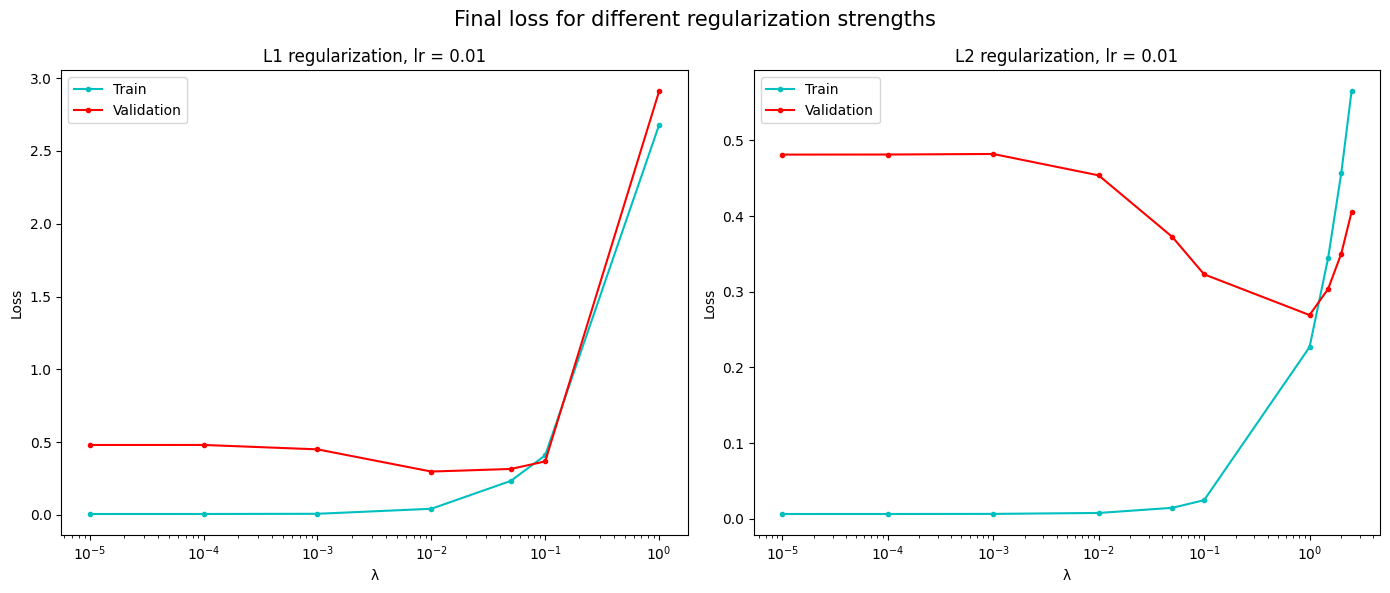

In [ ]:
# Loss plots vs regularization strength

reg_list = [0.00001, 0.0001, 0.001, 0.01, 0.05, 0.1, 1]
reg_list_ridge = [0.00001, 0.0001, 0.001, 0.01, 0.05, 0.1, 1, 1.5, 2, 2.5]
lr_list_3_3 = [0.001, 0.005, 0.01]


fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# L1 regularization
ax = plt.subplot(1, 2, 1)
all_train_loss_1 = []
all_val_loss_1 = []

for reg_strength in reg_list:
    model = l1_all_models_v2[(lasso_best_lr_3_3_loss, reg_strength)]
    all_train_loss_1.append(model.train_loss_history[-1])
    all_val_loss_1.append(model.val_loss_history[-1])

ax.plot(reg_list, all_train_loss_1, 'c.-', label='Train')
ax.plot(reg_list, all_val_loss_1, 'r.-', label='Validation')

ax.set_xscale("log")
ax.set_xlabel("λ")
ax.set_ylabel("Loss")
ax.set_title(f"L1 regularization, lr = {lasso_best_lr_3_3_loss}")
ax.legend()


# L2 regularization
ax = plt.subplot(1, 2, 2)
all_train_loss_2 = []
all_val_loss_2 = []

for reg_strength in reg_list_ridge:
    model = l2_all_models_v3[(ridge_best_lr_3_3_loss, reg_strength)]
    all_train_loss_2.append(model.train_loss_history[-1])
    all_val_loss_2.append(model.val_loss_history[-1])

ax.plot(reg_list_ridge, all_train_loss_2, 'c.-', label='Train')
ax.plot(reg_list_ridge, all_val_loss_2, 'r.-', label='Validation')

ax.set_xscale("log")
ax.set_xlabel("λ")
ax.set_ylabel("Loss")
ax.set_title(f"L2 regularization, lr = {ridge_best_lr_3_3_loss}")
ax.legend()

fig.suptitle(f"Final loss for different regularization strengths", fontsize=15)
plt.tight_layout()
plt.show()

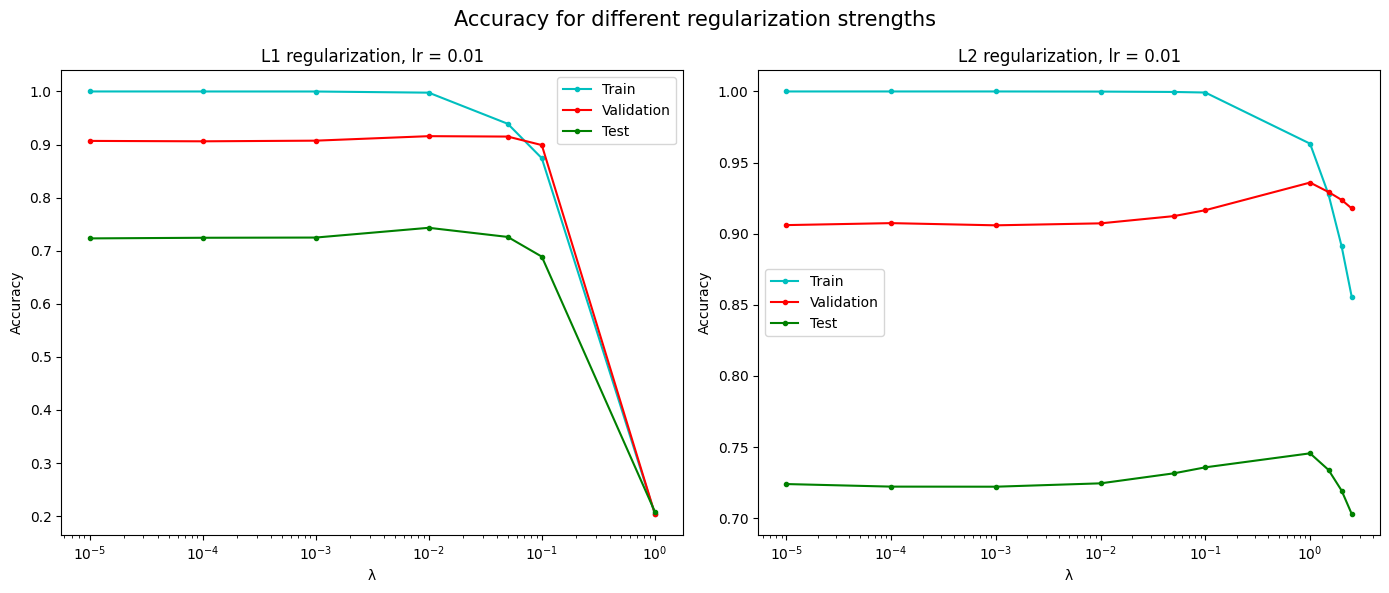

In [ ]:
# Accuracy plots vs regularization strength

reg_list = [0.00001, 0.0001, 0.001, 0.01, 0.05, 0.1, 1]
reg_list_ridge = [0.00001, 0.0001, 0.001, 0.01, 0.05, 0.1, 1, 1.5, 2, 2.5]
lr_list_3_3 = [0.001, 0.005, 0.01]


fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# L1 regularization
ax = plt.subplot(1, 2, 1)
all_train_acc_1 = []
all_val_acc_1 = []
all_test_acc_1 = []

for reg_strength in reg_list:
    train_acc, val_acc, test_acc = l1_all_accuracies_v2[(lasso_best_lr_3_3_loss, reg_strength)]
    all_train_acc_1.append(train_acc)
    all_val_acc_1.append(val_acc)
    all_test_acc_1.append(test_acc)

ax.plot(reg_list, all_train_acc_1, 'c.-', label='Train')
ax.plot(reg_list, all_val_acc_1, 'r.-', label='Validation')
ax.plot(reg_list, all_test_acc_1, 'g.-', label='Test')

ax.set_xscale("log")
ax.set_xlabel("λ")
ax.set_ylabel("Accuracy")
ax.set_title(f"L1 regularization, lr = {lasso_best_lr_3_3_loss}")
ax.legend()


# L2 regularization
ax = plt.subplot(1, 2, 2)
all_train_acc_2 = []
all_val_acc_2 = []
all_test_acc_2 = []

for reg_strength in reg_list_ridge:
    train_acc, val_acc, test_acc = l2_all_accuracies_v3[(ridge_best_lr_3_3_loss, reg_strength)]
    all_train_acc_2.append(train_acc)
    all_val_acc_2.append(val_acc)
    all_test_acc_2.append(test_acc)

ax.plot(reg_list_ridge, all_train_acc_2, 'c.-', label='Train')
ax.plot(reg_list_ridge, all_val_acc_2, 'r.-', label='Validation')
ax.plot(reg_list_ridge, all_test_acc_2, 'g.-', label='Test')

ax.set_xscale("log")
ax.set_xlabel("λ")
ax.set_ylabel("Accuracy")
ax.set_title(f"L2 regularization, lr = {ridge_best_lr_3_3_loss}")
ax.legend()

fig.suptitle(f"Accuracy for different regularization strengths", fontsize=15)
plt.tight_layout()
plt.show()

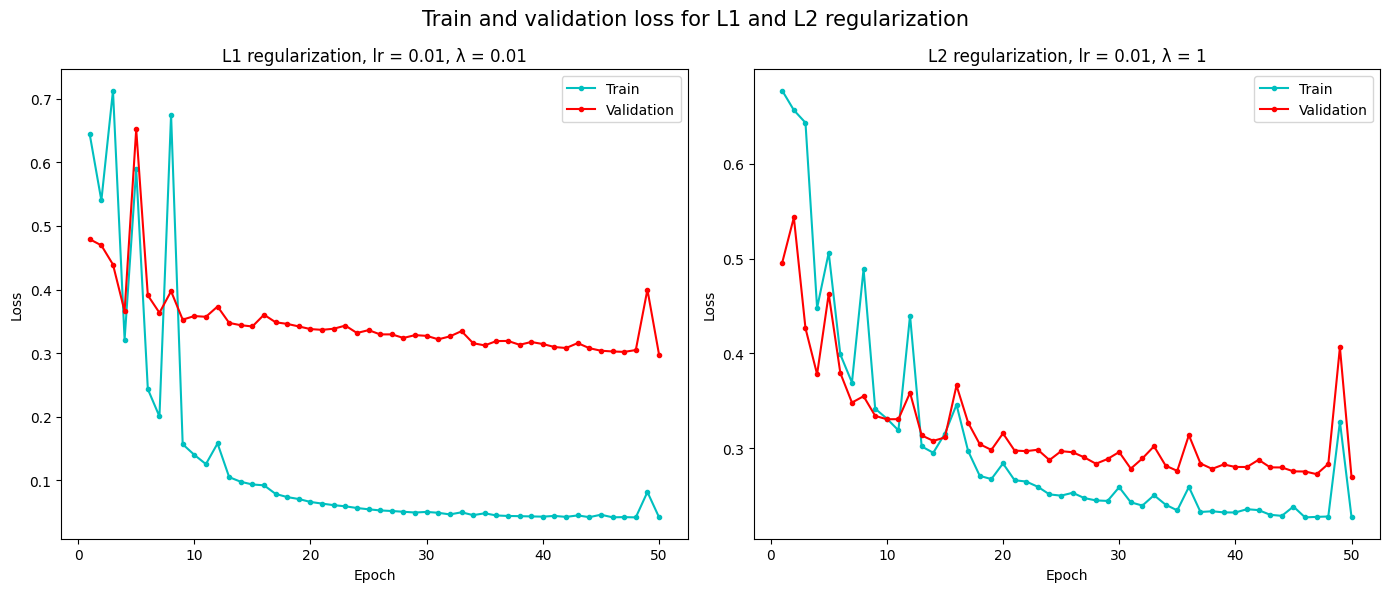

In [ ]:
# Loss vs epoch plots for models with lowest validation error

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))
epoch_list = np.arange(1, 51)

# L1 regularization
ax = plt.subplot(1, 2, 1)
best_lasso_model = l1_all_models_v2[(lasso_best_lr_3_3_loss, lasso_reg_3_3_loss)]

ax.plot(epoch_list, best_lasso_model.train_loss_history, 'c.-', label='Train')
ax.plot(epoch_list, best_lasso_model.val_loss_history, 'r.-', label='Validation')

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title(f"L1 regularization, lr = {lasso_best_lr_3_3_loss}, λ = {lasso_reg_3_3_loss}")
ax.legend()

# L2 regularization
ax = plt.subplot(1, 2, 2)
best_ridge_model = l2_all_models_v3[(ridge_best_lr_3_3_loss, ridge_reg_3_3_loss)]

ax.plot(epoch_list, best_ridge_model.train_loss_history, 'c.-', label='Train')
ax.plot(epoch_list, best_ridge_model.val_loss_history, 'r.-', label='Validation')

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title(f"L2 regularization, lr = {ridge_best_lr_3_3_loss}, λ = {ridge_reg_3_3_loss}")
ax.legend()

fig.suptitle(f"Train and validation loss for L1 and L2 regularization", fontsize=15)
plt.tight_layout()
plt.show()

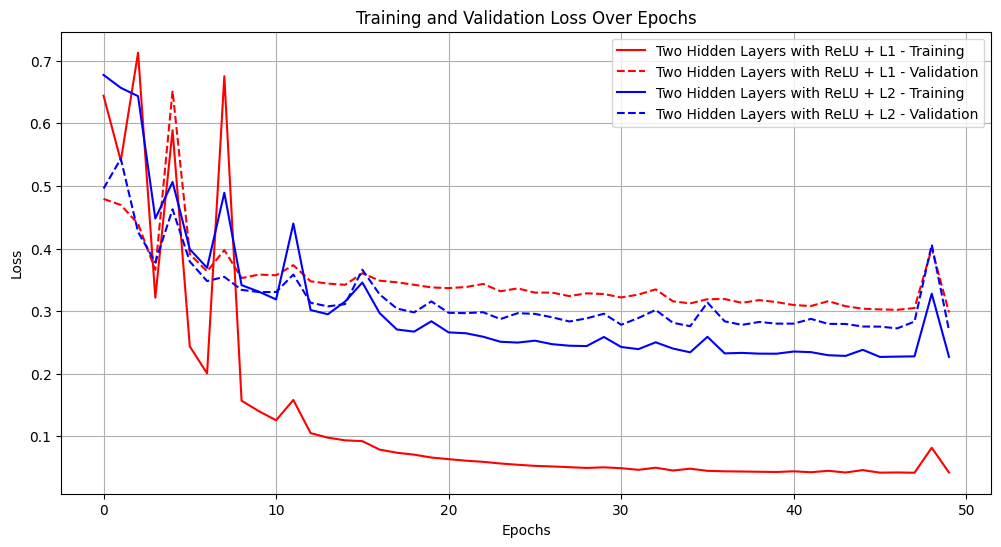

In [ ]:
models = [best_lasso_model, best_ridge_model]
labels = ["Two Hidden Layers with ReLU + L1", "Two Hidden Layers with ReLU + L2"]
plot_loss_curves(models, labels)

#### Save results

In [ ]:
fobj = open(f'drive/MyDrive/COMP551_A3/3.2_results.pkl', 'rb')
results = pickle.load(fobj)
fobj.close()

In [ ]:
# Save results
results["Two Hidden Layers (ReLU + L1)"] = l1_all_accuracies_v2[(lasso_best_lr_3_3_loss, lasso_reg_3_3_loss)]
results["Two Hidden Layers (ReLU + L2)"] = l2_all_accuracies_v3[(ridge_best_lr_3_3_loss, ridge_reg_3_3_loss)]

fobj = open(f'drive/MyDrive/COMP551_A3/3.3_results.pkl', 'wb')
pickle.dump(results, fobj)
fobj.close()

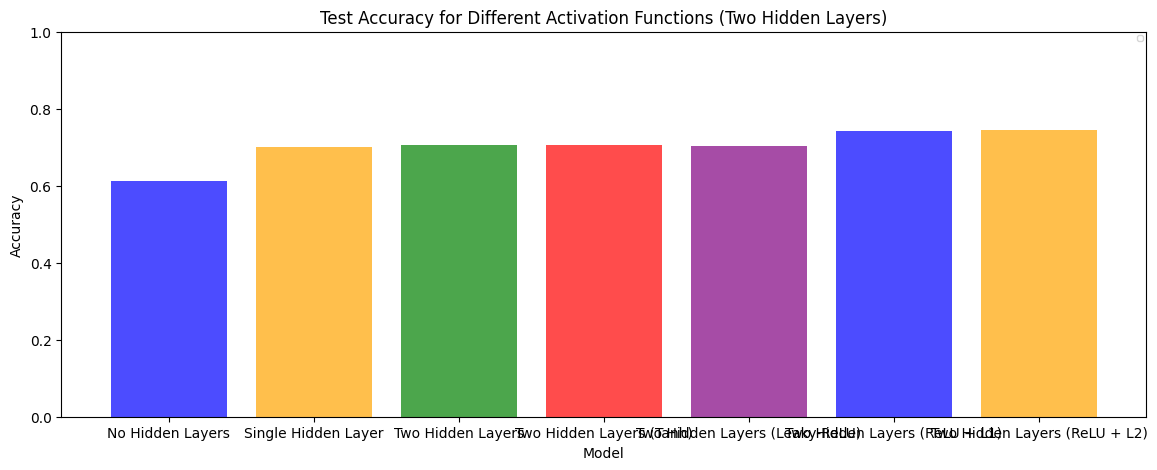


Comparison of Activation Functions (all up until now):
                                Train Accuracy  Validation Accuracy  \
No Hidden Layers                      0.769364             0.828378   
Single Hidden Layer                   0.902810             0.892158   
Two Hidden Layers                     0.931802             0.901402   
Two Hidden Layers (Tanh)              0.994271             0.902018   
Two Hidden Layers (Leaky-ReLU)        0.931194             0.902172   
Two Hidden Layers (ReLU + L1)         0.997685             0.915729   
Two Hidden Layers (ReLU + L2)         0.963253             0.935911   

                                Test Accuracy  
No Hidden Layers                     0.612555  
Single Hidden Layer                  0.699629  
Two Hidden Layers                    0.704579  
Two Hidden Layers (Tanh)             0.706885  
Two Hidden Layers (Leaky-ReLU)       0.704410  
Two Hidden Layers (ReLU + L1)        0.743109  
Two Hidden Layers (ReLU + L2)        0.

In [ ]:
# Plot Test Accuracy for all models
test_accuracies = {model: acc[2] for model, acc in results.items()}
plt.figure(figsize=(14, 5))
plt.bar(test_accuracies.keys(), test_accuracies.values(), color=['blue', 'orange', 'green', 'red', 'purple'], alpha=0.7)
plt.title("Test Accuracy for Different Activation Functions (Two Hidden Layers)")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

# Print results in table format
results_df = pd.DataFrame.from_dict(results, orient='index', columns=["Train Accuracy", "Validation Accuracy", "Test Accuracy"])
print("\nComparison of Activation Functions (all up until now):")
print(results_df)

To directly compare the effect of normalizing the images on model and training performance, we will use the same hyperparameter configuration found via grid search earlier.


*   Learning rate = 0.001
*   Batch size = 64



#### Unnormalized images

In [ ]:
# Transformation without normalizing data, but including tensor conversion and flattening
transform_flatten = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))
])

# Apply the transform to the datasets
train_loader_no_norm = DataLoader(
    OrganAMNIST(split="train", transform=transform_flatten, download=True),
    batch_size=64,
    shuffle=True
)

val_loader_no_norm = DataLoader(
    OrganAMNIST(split="val", transform=transform_flatten, download=True),
    batch_size=64,
    shuffle=False
)

test_loader_no_norm = DataLoader(
    OrganAMNIST(split="test", transform=transform_flatten, download=True),
    batch_size=64,
    shuffle=False
)

# Convert the unnormalized DataLoader to NumPy arrays
X_train_no_norm, y_train_no_norm = data_loader_to_numpy(train_loader_no_norm)
X_val_no_norm, y_val_no_norm = data_loader_to_numpy(val_loader_no_norm)
X_test_no_norm, y_test_no_norm = data_loader_to_numpy(test_loader_no_norm)

# Check the range of pixel values to confirm they are unnormalized
print("Train Data Range (Unnormalized):", X_train_no_norm.min(), X_train_no_norm.max())
print("Validation Data Range (Unnormalized):", X_val_no_norm.min(), X_val_no_norm.max())
print("Test Data Range (Unnormalized):", X_test_no_norm.min(), X_test_no_norm.max())

Using downloaded and verified file: /root/.medmnist/organamnist.npz
Using downloaded and verified file: /root/.medmnist/organamnist.npz
Using downloaded and verified file: /root/.medmnist/organamnist.npz
Train Data Range (Unnormalized): 0.0 1.0
Validation Data Range (Unnormalized): 0.0 1.0
Test Data Range (Unnormalized): 0.0 1.0


In [ ]:
# Check shapes
print("Unnormalized Data Shapes:")
print("X_train shape:", X_train_no_norm.shape)
print("y_train shape:", y_train_no_norm.shape)
print("X_val shape:", X_val_no_norm.shape)
print("y_val shape:", y_val_no_norm.shape)
print("X_test shape:", X_test_no_norm.shape)
print("y_test shape:", y_test_no_norm.shape)

Unnormalized Data Shapes:
X_train shape: (34561, 784)
y_train shape: (34561,)
X_val shape: (6491, 784)
y_val shape: (6491,)
X_test shape: (17778, 784)
y_test shape: (17778,)


#### Training

In [ ]:
# Using same parameters
lr=0.001
batch_size=64

# Define MLP with two hidden layers and ReLU
model_unnormalized = MLP(
    activation_function='relu',
    num_hidden_layers=2,
    hidden_units=[256, 256],
    input_dim=X_train_no_norm.shape[1],
    output_dim=11,
    learning_rate=lr,
)

# Train and evaluate the model
print("\nTraining MLP with Unnormalized Images:")
start_time = time.time()
results_unorm = run_experiment(model_unnormalized, X_train_no_norm, y_train_no_norm, X_val_no_norm, y_val_no_norm, X_test_no_norm, y_test_no_norm, batch_size=batch_size)
end_time = time.time()

# Display timing and results
print(f"\nTraining Time (Unnormalized Data): {end_time - start_time:.2f} seconds")

# Save model and results
fobj = open(f'drive/MyDrive/COMP551_A3/3.4_model.pkl', 'wb')
pickle.dump(model_unnormalized, fobj)
fobj.close()

fobj = open(f'drive/MyDrive/COMP551_A3/3.4_only_results.pkl', 'wb')
pickle.dump(results_unorm, fobj)
fobj.close()

# Compare results
print("\nResults (Unnormalized Data):")
print(f"Train Accuracy: {results_unorm[0]:.4f}")
print(f"Validation Accuracy: {results_unorm[1]:.4f}")
print(f"Test Accuracy: {results_unorm[2]:.4f}")


Training MLP with Unnormalized Images:
Epoch 1/50, Training loss: 1.8134, Accuracy: 0.4353
Epoch 10/50, Training loss: 0.9697, Accuracy: 0.6955
Epoch 20/50, Training loss: 0.8174, Accuracy: 0.7304
Epoch 30/50, Training loss: 0.7652, Accuracy: 0.7310
Epoch 40/50, Training loss: 0.6613, Accuracy: 0.7781
Epoch 50/50, Training loss: 0.6017, Accuracy: 0.8009
Train Accuracy: 0.8009
Validation Accuracy: 0.8940
Test Accuracy: 0.6616

Training Time (Unnormalized Data): 539.13 seconds

Results (Unnormalized Data):
Train Accuracy: 0.8009
Validation Accuracy: 0.8940
Test Accuracy: 0.6616


#### Plots

In [ ]:
# Load the model and results
fobj = open(f'drive/MyDrive/COMP551_A3/3.4_model.pkl', 'rb')
model_unnormalized = pickle.load(fobj)
fobj.close()

fobj = open(f'drive/MyDrive/COMP551_A3/3.4_only_results.pkl', 'rb')
results_unorm = pickle.load(fobj)
fobj.close()

fobj = open(f'drive/MyDrive/COMP551_A3/3.3_results.pkl', 'rb')
results = pickle.load(fobj)
fobj.close()

In [ ]:
# Save results
results["Two Hidden Layers (Unnormalized)"] = results_unorm

fobj = open(f'drive/MyDrive/COMP551_A3/3.4_results.pkl', 'wb')
pickle.dump(results, fobj)
fobj.close()

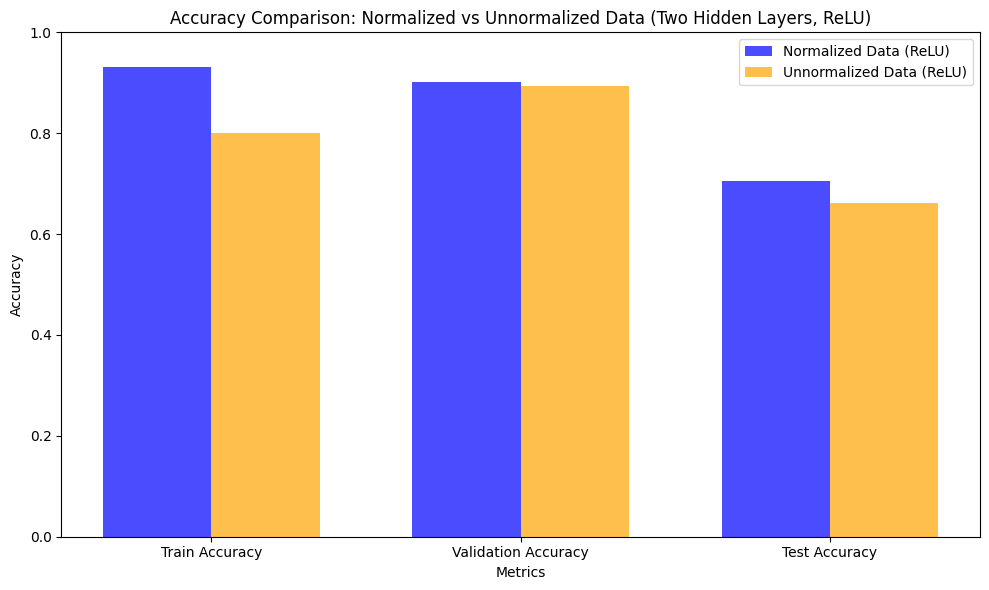

In [ ]:
# Extract train, validation, and test accuracies for normalized and unnormalized models
normalized_accuracies = [
    results.get("Two Hidden Layers", [0, 0, 0])[0],  # Train accuracy (normalized)
    results.get("Two Hidden Layers", [0, 0, 0])[1],  # Validation accuracy (normalized)
    results.get("Two Hidden Layers", [0, 0, 0])[2],  # Test accuracy (normalized)
]

unnormalized_accuracies = [
    results_unorm[0],  # Train accuracy (unnormalized)
    results_unorm[1],  # Validation accuracy (unnormalized)
    results_unorm[2],  # Test accuracy (unnormalized)
]

# Labels for the x-axis
metrics = ["Train Accuracy", "Validation Accuracy", "Test Accuracy"]

# Bar plot positions
x = np.arange(len(metrics))  # [0, 1, 2]
width = 0.35  # Width of the bars

# Plot the grouped bar chart
plt.figure(figsize=(10, 6))
plt.bar(x - width / 2, normalized_accuracies, width, label="Normalized Data (ReLU)", color="blue", alpha=0.7)
plt.bar(x + width / 2, unnormalized_accuracies, width, label="Unnormalized Data (ReLU)", color="orange", alpha=0.7)

# Add titles and labels
plt.title("Accuracy Comparison: Normalized vs Unnormalized Data (Two Hidden Layers, ReLU)")
plt.xlabel("Metrics")
plt.ylabel("Accuracy")
plt.ylim(0, 1)  # Ensure y-axis is between 0 and 1
plt.xticks(x, metrics)  # Add x-axis labels
plt.legend()  # Add legend

# Show the plot
plt.tight_layout()
plt.show()

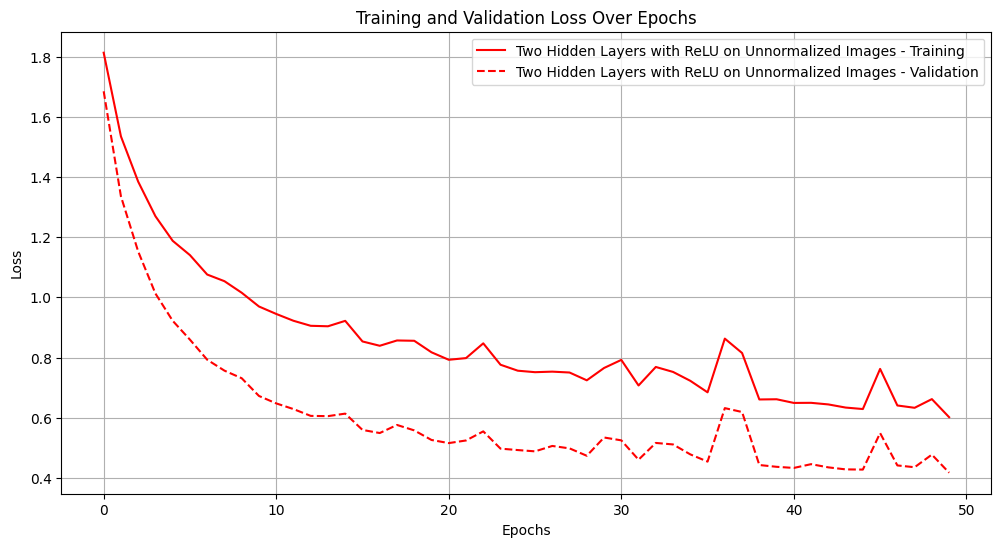

In [ ]:
# List of models and their labels
models = [model_unnormalized]
labels = ["Two Hidden Layers with ReLU on Unnormalized Images"]

# Plot the loss curves
plot_loss_curves(models, labels)

Once again, we shall use the same hyperparameter configuration found via grid search earlier in order to directly compare the effect of normalizing the images on model and training performance and training time.

#### Dataset

In [ ]:
# Set a seed for reproducibility
set_seed(42)

# Calculate the mean and standard deviation for OrganAMNIST, size=128
mean128, std128 = mean_var_calc('OrganAMNIST', size=128)
print("Calculated Mean:", mean128)
print("Calculated Standard Deviation:", std128)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[mean128], std=[std128]),   # Normalize using calculated mean and std
    transforms.Lambda(lambda x: x.view(-1))               # Flatten the images
])

100%|██████████| 708M/708M [00:36<00:00, 19.2MB/s]


Calculated Mean: 0.46803364157676697
Calculated Standard Deviation: 0.28756338357925415


In [ ]:
# Load dataset with 128x128 size images
train_data_128 = OrganAMNIST(split="train", transform=transform, download=True, size=128)
val_data_128 = OrganAMNIST(split="val", transform=transform, download=True, size=128)
test_data_128 = OrganAMNIST(split="test", transform=transform, download=True, size=128)

# DataLoader
train_loader_128 = DataLoader(train_data_128, batch_size=64, shuffle=True)
val_loader_128 = DataLoader(val_data_128, batch_size=64, shuffle=False)
test_loader_128 = DataLoader(test_data_128, batch_size=64, shuffle=False)

Using downloaded and verified file: /root/.medmnist/organamnist_128.npz
Using downloaded and verified file: /root/.medmnist/organamnist_128.npz
Using downloaded and verified file: /root/.medmnist/organamnist_128.npz


In [ ]:
# Convert DataLoader to NumPy arrays
X_train_128, y_train_128 = data_loader_to_numpy(train_loader_128)
X_val_128, y_val_128 = data_loader_to_numpy(val_loader_128)
X_test_128, y_test_128 = data_loader_to_numpy(test_loader_128)

# Check shapes
print("128-pixel Corrected Data Shapes:")
print("X_train_128 shape:", X_train_128.shape)
print("y_train_128 shape:", y_train_128.shape)
print("X_val_128 shape:", X_val_128.shape)
print("y_val_128 shape:", y_val_128.shape)
print("X_test_128 shape:", X_test_128.shape)
print("y_test_128 shape:", y_test_128.shape)

128-pixel Corrected Data Shapes:
X_train_128 shape: (34561, 16384)
y_train_128 shape: (34561,)
X_val_128 shape: (6491, 16384)
y_val_128 shape: (6491,)
X_test_128 shape: (17778, 16384)
y_test_128 shape: (17778,)


#### Training

In [ ]:
# Define the MLP with the correct input size
model128 = MLP(
    activation_function='relu',
    num_hidden_layers=2,
    hidden_units=[256, 256],
    input_dim=16384,                  # 128x128 pixels
    output_dim=11,
    learning_rate=0.001
)

# Train and evaluate the corrected model
print("\nTraining MLP with Corrected 128-pixel Normalized Images:")
start_time = time.time()
results_128 = run_experiment(model128, X_train_128, y_train_128, X_val_128, y_val_128, X_test_128, y_test_128, num_iterations=50, batch_size=64)
end_time = time.time()

# Display timing and results
print(f"\nTraining Time (128-pixel version): {end_time - start_time:.2f} seconds")


# Save model and results
fobj = open(f'drive/MyDrive/COMP551_A3/3.5_model.pkl', 'wb')
pickle.dump(model128, fobj)
fobj.close()

fobj = open(f'drive/MyDrive/COMP551_A3/3.5_only_results.pkl', 'wb')
pickle.dump(results_128, fobj)
fobj.close()


results_df_128 = pd.DataFrame(
    [results_128],
    columns=["Train Accuracy", "Validation Accuracy", "Test Accuracy"],
    index=["128-pixel Model (Corrected)"]
)
print("\nResults (Corrected 128-pixel Normalized Data):")
print(results_df_128)


Training MLP with Corrected 128-pixel Normalized Images:
Epoch 1/50, Training loss: 0.5997, Accuracy: 0.8105
Epoch 10/50, Training loss: 0.1639, Accuracy: 0.9669
Epoch 20/50, Training loss: 0.0849, Accuracy: 0.9867
Epoch 30/50, Training loss: 0.0523, Accuracy: 0.9937
Epoch 40/50, Training loss: 0.0361, Accuracy: 0.9965
Epoch 50/50, Training loss: 0.0266, Accuracy: 0.9976
Train Accuracy: 0.9976
Validation Accuracy: 0.9156
Test Accuracy: 0.7462

Training Time (128-pixel version): 2192.91 seconds

Results (Corrected 128-pixel Normalized Data):
                             Train Accuracy  Validation Accuracy  \
128-pixel Model (Corrected)        0.997627             0.915575   

                             Test Accuracy  
128-pixel Model (Corrected)       0.746203  


#### Plots

In [ ]:
# Load model and results
fobj = open(f'drive/MyDrive/COMP551_A3/3.5_model.pkl', 'rb')
model128 = pickle.load(fobj)
fobj.close()

def helper_experiment(model, X_train, y_train, X_val, y_val, X_test=None, y_test=None, num_iterations=50, batch_size=64, print_test=True):
    # Train accuracy
    y_pred_train = model.predict(X_train)
    accuracy_train = model.evaluate_acc(y_train, y_pred_train)
    print(f'Train Accuracy: {accuracy_train:.4f}')

    # Validation accuracy
    y_pred_val = model.predict(X_val)
    accuracy_val = model.evaluate_acc(y_val, y_pred_val)
    print(f'Validation Accuracy: {accuracy_val:.4f}')

    # Test accuracy
    accuracy_test = None

    if X_test is not None and y_test is not None:
        y_pred_test = model.predict(X_test)
        accuracy_test = model.evaluate_acc(y_test, y_pred_test)

        if print_test:
            print(f'Test Accuracy: {accuracy_test:.4f}')

    return accuracy_train, accuracy_val, accuracy_test

In [ ]:
# Load model and results
fobj = open(f'drive/MyDrive/COMP551_A3/3.5_model.pkl', 'rb')
model128 = pickle.load(fobj)
fobj.close()

fobj = open(f'drive/MyDrive/COMP551_A3/3.5_only_results.pkl', 'rb')
results_128 = pickle.load(fobj)
fobj.close()

fobj = open(f'drive/MyDrive/COMP551_A3/3.4_results.pkl', 'rb')
results = pickle.load(fobj)
fobj.close()

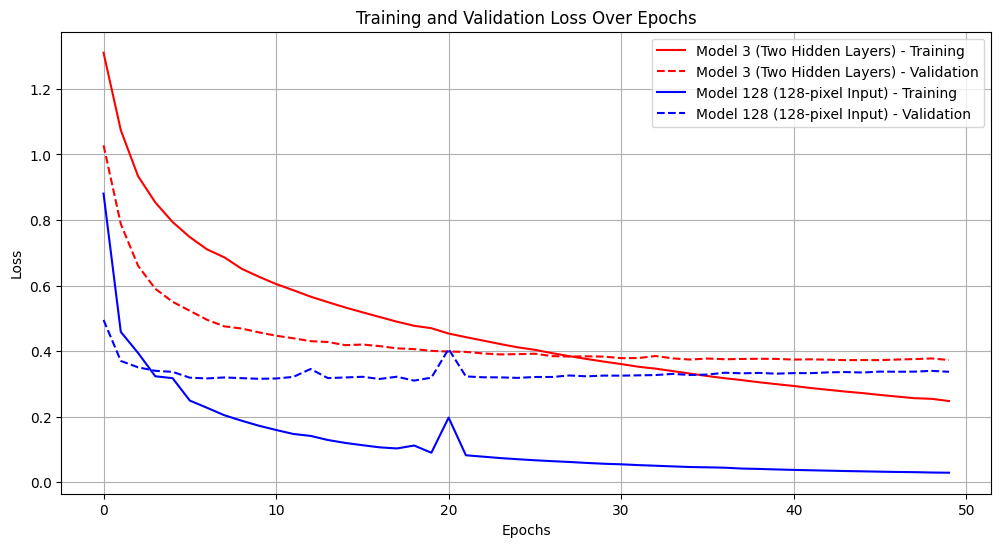

In [ ]:
# List of models and their labels

fobj = open(f'drive/MyDrive/COMP551_A3/3.1_three_models.pkl', 'rb')
models_3_1 = pickle.load(fobj)
fobj.close()

model3 = models_3_1[2]

models = [model3, model128]
labels = ["Model 3 (Two Hidden Layers)", "Model 128 (128-pixel Input)"]

# Plot the loss curves for Model 3 and Model 128
plot_loss_curves(models, labels)

In [ ]:
p

([<matplotlib.axis.XTick at 0x7e1d20cfee30>,
 [Text(0.3, 0, '28x28 pixel, 2 hidden layers'),
  Text(1.3, 0, '128x128 pixel, 2 hidden layers')])

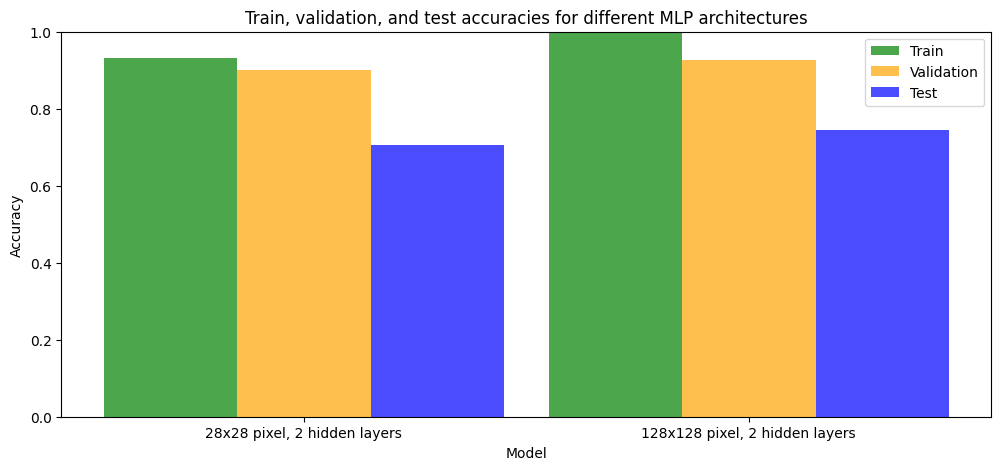

In [ ]:
train_accuracies = { "28x28 pixel, 2 hidden layers": results.get("Two Hidden Layers", [0, 0, 0])[0],
                    "128x128 pixel, 2 hidden layers": results_128[0]}

val_accuracies = { "28x28 pixel, 2 hidden layers": results.get("Two Hidden Layers", [0, 0, 0])[1],
                    "128x128 pixel, 2 hidden layers": results_128[1]}

test_accuracies = { "28x28 pixel, 2 hidden layers": results.get("Two Hidden Layers", [0, 0, 0])[2],
                    "128x128 pixel, 2 hidden layers": results_128[2]}

ind = np.arange(2)
plt.figure(figsize=(12,5))
width = 0.3

# Plotting
plt.bar(ind, train_accuracies.values(), width, color='green', alpha=0.7, label='Train')
plt.bar(ind + width, val_accuracies.values(), width, color='orange', alpha=0.7, label='Validation')
plt.bar(ind + 2*width, test_accuracies.values(), width, color='blue', alpha=0.7, label='Test')

plt.title("Train, validation, and test accuracies for different MLP architectures")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.legend(loc='best')
plt.ylim(0, 1)

plt.xticks(ind + width, train_accuracies.keys())

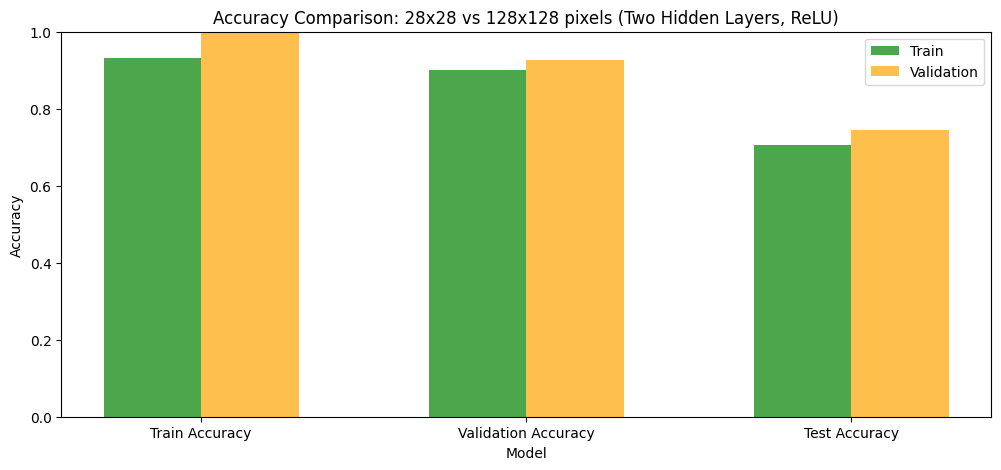

In [ ]:
# Extract train, validation, and test accuracies for normalized and unnormalized models
normalized_accuracies = { 'Train Accuracy' : results.get("Two Hidden Layers", [0, 0, 0])[0],
                    'Validation Accuracy': results.get("Two Hidden Layers", [0, 0, 0])[1],
                    'Test Accuracy':  results.get("Two Hidden Layers", [0, 0, 0])[2]}

accuracies_128 = { 'Train Accuracy': results_128[0],
                    'Validation Accuracy': results_128[1],
                    'Test Accuracy':  results_128[2]}

ind = np.arange(3)
plt.figure(figsize=(12,5))
width = 0.3

# Plotting
plt.bar(ind, normalized_accuracies.values(), width, color='green', alpha=0.7, label='Train')
plt.bar(ind + width, accuracies_128.values(), width, color='orange', alpha=0.7, label='Validation')

plt.title("Accuracy Comparison: 28x28 vs 128x128 pixels (Two Hidden Layers, ReLU)")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.legend(loc='best')
plt.ylim(0, 1)

plt.xticks(ind + width/2, normalized_accuracies.keys())

plt.show()

X_test shape before flattening: (17778, 16384)
X_test_flattened shape: (17778, 16384)
Model's expected input dimension: 16384


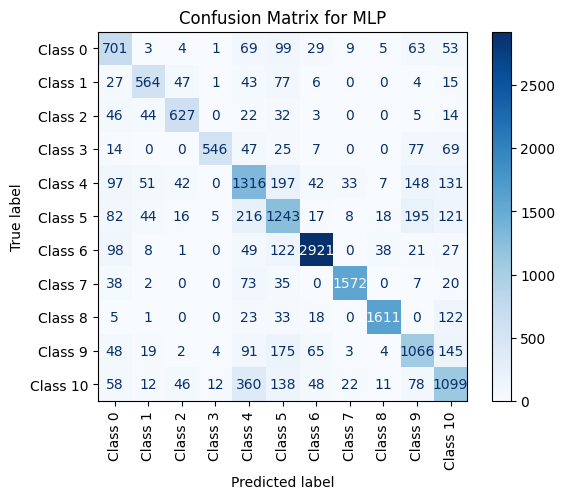

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Function to compute and display the confusion matrix
def compute_confusion_matrix_mlp(model, X_test128, y_test128, class_names):
    # Get predictions from the MLP
    y_pred128 = model.predict(X_test128)

    # Compute the confusion matrix
    cm = confusion_matrix(y_test128, y_pred128)

    # Display the confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation="vertical")
    plt.title("Confusion Matrix for MLP")
    plt.show()

    return cm

# Assuming the test data and class names are defined
class_names = ['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4',
               'Class 5', 'Class 6', 'Class 7', 'Class 8', 'Class 9', 'Class 10']

print("X_test shape before flattening:", X_test_128.shape)

# Ensure test data is reshaped to match the input dimensions for 128x128 images
X_test_flattened = X_test_128.reshape(X_test_128.shape[0], -1)  # Flatten to (num_samples, 128*128)

print("X_test_flattened shape:", X_test_flattened.shape)

print("Model's expected input dimension:", model128.weights[0].shape[0])

# Verify that the flattened input matches the model's expected input size
assert X_test_flattened.shape[1] == model128.weights[0].shape[0], \
    f"Input dimension {X_test_flattened.shape[1]} does not match model's input dimension {model128.weights[0].shape[0]}."

# Compute and display the confusion matrix
confusion_matrix_mlp = compute_confusion_matrix_mlp(model128, X_test_flattened, y_test_128, class_names)


### Best MLP model

In [ ]:
print(len(results))

9


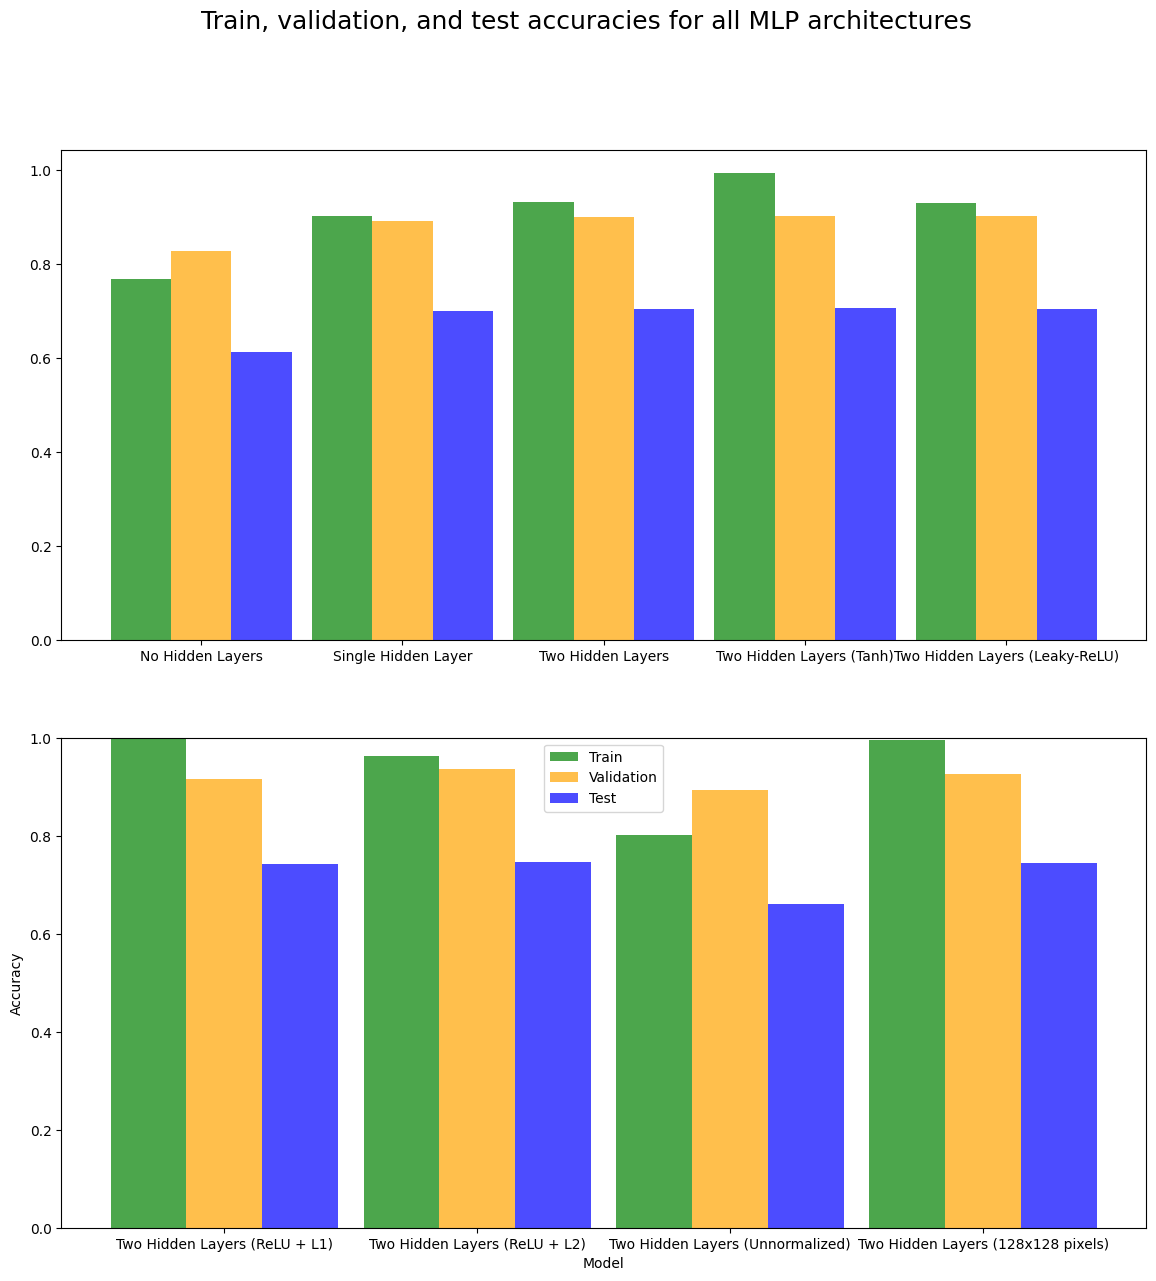

In [ ]:
# Plot accuracies

train_accuracies = {model: acc[0] for model, acc in results.items()}
val_accuracies = {model: acc[1] for model, acc in results.items()}
test_accuracies = {model: acc[2] for model, acc in results.items()}


fig, axs = plt.subplots(2, 1, figsize=(14, 14))

train_accuracies_1 = {}
train_accuracies_2 = {}
val_accuracies_1 = {}
val_accuracies_2 = {}
test_accuracies_1 = {}
test_accuracies_2 = {}

idx = 0

for model, acc in results.items():
    if idx < 5:
        train_accuracies_1[model] = acc[0]
        val_accuracies_1[model] = acc[1]
        test_accuracies_1[model] = acc[2]
    else:
        train_accuracies_2[model] = acc[0]
        val_accuracies_2[model] = acc[1]
        test_accuracies_2[model] = acc[2]
    idx += 1


width = 0.3

# Plotting
ind = np.arange(5)
ax = plt.subplot(2, 1, 1)
ax.bar(ind, train_accuracies_1.values(), width, color='green', alpha=0.7, label='Train')
ax.bar(ind + width, val_accuracies_1.values(), width, color='orange', alpha=0.7, label='Validation')
ax.bar(ind + 2*width, test_accuracies_1.values(), width, color='blue', alpha=0.7, label='Test')
ax.set_xticks(ind + width, train_accuracies_1.keys())

ind = np.arange(4)
ax = plt.subplot(2, 1, 2)
ax.bar(ind, train_accuracies_2.values(), width, color='green', alpha=0.7, label='Train')
ax.bar(ind + width, val_accuracies_2.values(), width, color='orange', alpha=0.7, label='Validation')
ax.bar(ind + 2*width, test_accuracies_2.values(), width, color='blue', alpha=0.7, label='Test')
ax.set_xticks(ind + width, train_accuracies_2.keys())

fig.suptitle("Train, validation, and test accuracies for all MLP architectures", size=18)
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.legend(loc='best')
plt.ylim(0, 1)
plt.show()

In [ ]:
# Print results in table format
import pandas as pd

results_df = pd.DataFrame.from_dict(results, orient='index', columns=["Train Accuracy", "Validation Accuracy", "Test Accuracy"])
print("\nComparison for all MLP models:")
print(results_df)


Comparison for all MLP models:
                                    Train Accuracy  Validation Accuracy  \
No Hidden Layers                          0.769364             0.828378   
Single Hidden Layer                       0.902810             0.892158   
Two Hidden Layers                         0.931802             0.901402   
Two Hidden Layers (Tanh)                  0.994271             0.902018   
Two Hidden Layers (Leaky-ReLU)            0.931194             0.902172   
Two Hidden Layers (ReLU + L1)             0.997685             0.915729   
Two Hidden Layers (ReLU + L2)             0.963253             0.935911   
Two Hidden Layers (Unnormalized)          0.800874             0.894007   
Two Hidden Layers (128x128 pixels)        0.995891             0.925589   

                                    Test Accuracy  
No Hidden Layers                         0.612555  
Single Hidden Layer                      0.699629  
Two Hidden Layers                        0.704579  
Two Hidde

### Conclusions
From this, we can see that the model that maximizes the test accuracy in the model using two hidden layers with ReLU activation and L2 regularization (lr=0.01, lambda=1). If we were to pick models based on their validation accuracy (since we do not do model selection by looking at the teste set), note that this same model maximizes the validation accuracy.